# Model B: Market Regime Identification

## Objective

The objective of Model B is to identify persistent market regimes from daily S&P 500 and VIX data using unsupervised learning.

The primary model is a **Gaussian Hidden Markov Model (HMM)**, which is used to classify market conditions into three economically interpretable states:

- **Calm**
- **Transition**
- **Stressed**

A **K-means clustering model** is used as a benchmark. While K-means evaluates how clearly observations separate in feature space, the HMM is the primary regime model because it also captures the **temporal persistence and transition structure** of market states.

The models are estimated using market features derived from:

- VIX level,
- day-over-day VIX change,
- 20-day realized volatility,
- 20-day return skewness,
- and 20-day return kurtosis.

The analysis uses a temporal train/test split, with **2000–2017** used for model estimation and **2018–2025** retained as a held-out period for evaluating regime stability.

## Role in the Overall Project

Model B forms the unsupervised learning component of the project. Its purpose is to convert market conditions into regime information that can subsequently be used as explanatory features in **Model A**, the supervised volatility-forecasting model.

The regime information allows Model A to incorporate not only current market variables, but also information about the broader market state in which those observations occur.

## Model Evaluation

The HMM and K-means solutions are evaluated using several complementary approaches:

- regime interpretability and prevalence,
- train/test regime stability,
- HMM transition probabilities and expected regime duration,
- geometric clustering metrics,
- agreement between HMM and K-means classifications,
- regime-switching frequency,
- and historical validation during the **Global Financial Crisis** and **COVID-19 market shock**.

This combination of diagnostics is intended to assess both the statistical structure and the economic relevance of the identified regimes.

## Outputs

The final Model B outputs include:

1. A full analytical dataset containing the original market features together with HMM regime assignments and posterior probabilities.
2. A compact regime-feature dataset for use in Model A containing:
   - `HMM_State`
   - `Regime`
   - `P_Calm`
   - `P_Transition`
   - `P_Stressed`
   - `Regime_Confidence`
3. A set of saved visualizations documenting regime selection, regime profiles, train/test stability, transition dynamics, K-means benchmarking, and historical stress-period performance.

These outputs provide the bridge between the unsupervised regime-identification stage and the supervised forward-volatility forecasting stage of the project.

----------------------------------------------------------------------

## 1. Setup and Data Loading

This section imports the libraries required for HMM estimation, data preparation, and visualization. It then loads the selected feature dataset produced in the **Model B: Feature Engineering** notebook.

The dataset will first be inspected to confirm its structure, date range, selected features, and missing values before any preprocessing is applied.

In [64]:
!pip install hmmlearn # since colab doesnt have this on default

In [65]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering benchmark
from sklearn.cluster import KMeans

# Model evaluation
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Hidden Markov Model
from hmmlearn.hmm import GaussianHMM

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [66]:
# Load the selected HMM features produced by the feature-engineering notebook

file_path = "/content/market_hmm_features_2000_2025.parquet"

df = pd.read_parquet(file_path)

# Ensure Date is stored as datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = (
    df
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6519, 7)


,Date,SP500_Close,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D
0,2000-02-01,1409.280029,23.45,-1.50,0.263633,-0.523001,0.454056
1,2000-02-02,1409.119995,23.12,-0.33,0.223332,-0.218100,0.560588
2,2000-02-03,1424.969971,22.01,-1.11,0.226596,-0.291496,0.391489
3,2000-02-04,1424.369995,21.54,-0.47,0.226637,-0.275308,0.381911
4,2000-02-07,1424.239990,22.79,1.25,0.204786,-0.503579,0.804882


In [67]:
# Basic Structure Inspection
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing"))

Columns:
['Date', 'SP500_Close', 'VIX_Level', 'VIX_Change', 'Realized_Vol_20D', 'Return_Skew_20D', 'Return_Kurt_20D']

Data types:
Date                datetime64[ns]
SP500_Close                float64
VIX_Level                  float64
VIX_Change                 float64
Realized_Vol_20D           float64
Return_Skew_20D            float64
Return_Kurt_20D            float64
dtype: object

Date range:
2000-02-01 00:00:00 to 2025-12-31 00:00:00

Missing values:


,Missing
Date,0
SP500_Close,0
VIX_Level,0
VIX_Change,0
Realized_Vol_20D,0
Return_Skew_20D,0
Return_Kurt_20D,0


## 2. HMM Modeling Dataset

The feature-engineering stage selected five variables for market-regime identification:

- **VIX_Level** — level of implied market volatility
- **VIX_Change** — day-over-day change in the VIX
- **Realized_Vol_20D** — trailing 20-day realized market volatility
- **Return_Skew_20D** — trailing 20-day return skewness
- **Return_Kurt_20D** — trailing 20-day return kurtosis

Together, these variables capture different dimensions of market conditions. VIX and realized volatility measure implied and observed market uncertainty, while skewness and kurtosis capture changes in the shape and tail behavior of the return distribution.

The 20-day trailing statistics represent approximately one trading month and provide a common horizon for describing recent market conditions.

`Date` and `SP500_Close` are retained for subsequent interpretation and visualization but are not directly used as HMM inputs.

In [68]:
# Features used by the Hidden Markov Model
hmm_features = [
    "VIX_Level",
    "VIX_Change",
    "Realized_Vol_20D",
    "Return_Skew_20D",
    "Return_Kurt_20D"
]

# Confirm that all required features are available
missing_features = [
    feature for feature in hmm_features
    if feature not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing required HMM features: {missing_features}"
    )

# Inspect modeling features
display(df[hmm_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
VIX_Level,6519.0,19.827786,8.377694,9.140000,13.980000,17.750000,23.210000,82.690000
VIX_Change,6519.0,-0.001534,1.814710,-18.710000,-0.720000,-0.090000,0.590000,24.860000
Realized_Vol_20D,6519.0,0.163517,0.106504,0.032837,0.097530,0.136986,0.198048,0.978970
Return_Skew_20D,6519.0,-0.091930,0.640762,-3.165727,-0.464373,-0.094620,0.308994,2.515150
Return_Kurt_20D,6519.0,0.472700,1.477884,-1.669611,-0.492753,0.125544,0.974381,12.447879


### 2.1 Temporal Train/Test Split

Because financial data are time ordered, the modeling dataset is divided chronologically rather than randomly.

The periods are defined as:

- **Training period:** 2000–2017
- **Test period:** 2018–2025

The training period is used to estimate the HMM parameters and preprocessing transformations. The test period is held out during model estimation and is later used to evaluate whether the identified regime structure remains meaningful in unseen market conditions.

This setup is particularly useful because the test period contains several important market environments, including the COVID-19 market shock and the subsequent inflation and monetary-tightening period.

No future observations are used when fitting the feature scaler or estimating the HMM.

In [69]:
# Define chronological training and test periods

TRAIN_END = "2017-12-31"
TEST_START = "2018-01-01"

train_df = df.loc[
    df["Date"] <= TRAIN_END
].copy()

test_df = df.loc[
    df["Date"] >= TEST_START
].copy()

# Summarize the split
split_summary = pd.DataFrame({
    "Start": [
        train_df["Date"].min().date(),
        test_df["Date"].min().date()
    ],
    "End": [
        train_df["Date"].max().date(),
        test_df["Date"].max().date()
    ],
    "Trading Days": [
        len(train_df),
        len(test_df)
    ]
}, index=["Training", "Test"])

display(split_summary)

,Start,End,Trading Days
Training,2000-02-01,2017-12-29,4508
Test,2018-01-02,2025-12-31,2011


### 2.2 Feature Standardization

The HMM input variables are measured on different numerical scales. Standardization prevents variables with larger numerical magnitudes from disproportionately influencing model estimation.

To preserve the separation between the training and test periods, the `StandardScaler` is fitted **only on the training data**. The same training-period transformation is then applied to the test observations.

This avoids introducing information from the held-out period into model estimation.

Extreme observations are retained because they may contain economically meaningful information about periods of market stress and are therefore relevant to regime identification.

In [70]:
# Separate training and test feature matrices
X_train_raw = train_df[hmm_features].copy()
X_test_raw = test_df[hmm_features].copy()

# Fit scaler using training data only
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)

# Apply the training transformation to test data
X_test = scaler.transform(X_test_raw)

# Apply the same scaler to the complete dataset
# for later full-period regime classification
X_all = scaler.transform(df[hmm_features])

print("Training feature matrix:", X_train.shape)
print("Test feature matrix:", X_test.shape)
print("Full feature matrix:", X_all.shape)

Training feature matrix: (4508, 5)
Test feature matrix: (2011, 5)
Full feature matrix: (6519, 5)


In [71]:
# Check mean and standard deviation after standardization

scaling_check = pd.DataFrame({
    "Mean": X_train.mean(axis=0),
    "Std": X_train.std(axis=0)
}, index=hmm_features)

display(scaling_check.round(4))

,Mean,Std
VIX_Level,-0.0,1.0
VIX_Change,0.0,1.0
Realized_Vol_20D,0.0,1.0
Return_Skew_20D,0.0,1.0
Return_Kurt_20D,0.0,1.0


## 3. Selecting the Number of Market Regimes

Before estimating the final HMM, several candidate models are evaluated using different numbers of hidden states.

Models with **2 to 6 regimes** are considered. For each candidate number of states, the HMM is fitted multiple times using different random initializations, and the best converged model is retained based on its training log-likelihood.

Model complexity is assessed using the **Bayesian Information Criterion (BIC)**. BIC balances model fit against the number of estimated parameters, penalizing increasingly complex models.

The regime-count decision is not based on BIC alone. Statistical fit is considered alongside:

- model convergence,
- regime stability,
- regime prevalence,
- persistence,
- and economic interpretability.

The project ultimately seeks a parsimonious regime structure that meaningfully distinguishes **Calm, Transition, and Stressed** market conditions.

In [72]:
# Helper Function 1
def fit_best_hmm(
    X,
    n_components,
    n_init=10,
    covariance_type="full",
    n_iter=1000,
    random_state=42
):
    """
    Fit multiple Gaussian HMM initializations and retain
    the converged model with the highest log-likelihood.
    """

    best_model = None
    best_log_likelihood = -np.inf
    best_seed = None

    for i in range(n_init):

        seed = random_state + i

        model = GaussianHMM(
            n_components=n_components,
            covariance_type=covariance_type,
            n_iter=n_iter,
            random_state=seed
        )

        try:
            model.fit(X)

            log_likelihood = model.score(X)

            if (
                model.monitor_.converged
                and log_likelihood > best_log_likelihood
            ):
                best_model = model
                best_log_likelihood = log_likelihood
                best_seed = seed

        except Exception as e:
            print(
                f"K={n_components}, seed={seed} failed: {e}"
            )

    return best_model, best_log_likelihood, best_seed

In [73]:
# Helper Function 2
def calculate_hmm_bic(model, X):
    """
    Calculate Bayesian Information Criterion (BIC)
    for a fitted Gaussian HMM with full covariance matrices.
    """

    n_samples, n_features = X.shape
    n_states = model.n_components

    # Initial state probabilities
    n_startprob_params = n_states - 1

    # Transition probabilities
    n_transmat_params = n_states * (n_states - 1)

    # Means
    n_mean_params = n_states * n_features

    # Full covariance matrices
    n_cov_params = (
        n_states
        * n_features
        * (n_features + 1)
        / 2
    )

    n_params = (
        n_startprob_params
        + n_transmat_params
        + n_mean_params
        + n_cov_params
    )

    log_likelihood = model.score(X)

    bic = (
        -2 * log_likelihood
        + n_params * np.log(n_samples)
    )

    return bic

In [74]:
candidate_states = range(2, 7)

model_selection_results = []

candidate_models = {}

for k in candidate_states:

    model, log_likelihood, seed = fit_best_hmm(
        X_train,
        n_components=k,
        n_init=10,
        covariance_type="full",
        n_iter=1000,
        random_state=RANDOM_STATE
    )

    if model is not None:

        bic = calculate_hmm_bic(
            model,
            X_train
        )

        candidate_models[k] = model

        model_selection_results.append({
            "States": k,
            "Log_Likelihood": log_likelihood,
            "BIC": bic,
            "Best_Seed": seed,
            "Converged": model.monitor_.converged
        })

model_selection_df = pd.DataFrame(
    model_selection_results
)

display(
    model_selection_df.round(2)
)

,States,Log_Likelihood,BIC,Best_Seed,Converged
0,2,-22677.09,45715.96,47,True
1,3,-19896.46,40365.04,44,True
2,4,-18168.24,37135.77,47,True
3,5,-16812.84,34668.98,51,True
4,6,-15795.42,32894.96,43,True


## Section Observation:
### 3.0 Initial Model-Selection Results

Model fit improves consistently as the number of hidden states increases. Log-likelihood becomes progressively less negative, while BIC declines from the 2-state through the 6-state specification.

Among the candidate models considered, the **6-state model achieves the lowest BIC**, indicating that the statistical fit gained from additional states is sufficiently large to offset the BIC complexity penalty.

However, BIC alone does not determine the final regime specification in this project. The purpose of the HMM is to identify a parsimonious and economically interpretable representation of broad market conditions rather than to maximize the number of statistically distinguishable latent states.

The candidate models are therefore examined further in terms of:

- regime prevalence,
- persistence,
- switching behavior,
- market characteristics of each state,
- stability between the training and test periods, and
- whether additional states represent economically distinct conditions or subdivisions of broader regimes.

Particular attention is given to whether a three-state specification provides a meaningful distinction between **Calm, Transition, and Stressed** market conditions.

## 3.1 Candidate State Diagnosis

In [75]:
candidate_state_summary = []

for k, model in candidate_models.items():

    states = model.predict(X_train)

    counts = pd.Series(states).value_counts(normalize=True)

    for state in range(k):

        candidate_state_summary.append({
            "States": k,
            "State": state,
            "Observations": (states == state).sum(),
            "Share": (states == state).mean()
        })

candidate_state_summary_df = pd.DataFrame(
    candidate_state_summary
)

display(
    candidate_state_summary_df
    .sort_values(["States", "State"])
    .round(4)
)

,States,State,Observations,Share
0,2,0,1715,0.3804
1,2,1,2793,0.6196
2,3,0,1602,0.3554
3,3,1,1193,0.2646
4,3,2,1713,0.3800
5,4,0,1329,0.2948
6,4,1,512,0.1136
7,4,2,1441,0.3197
8,4,3,1226,0.2720
9,5,0,930,0.2063


In [76]:
candidate_profiles = []

for k, model in candidate_models.items():

    states = model.predict(X_train)

    temp = train_df.copy()
    temp["State"] = states

    profiles = (
        temp
        .groupby("State")[hmm_features]
        .mean()
        .reset_index()
    )

    profiles.insert(0, "States", k)

    candidate_profiles.append(profiles)

candidate_profiles_df = pd.concat(
    candidate_profiles,
    ignore_index=True
)

display(
    candidate_profiles_df.round(4)
)

,States,State,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D
0,2,0,27.9991,-0.0004,0.2524,0.0082,0.1383
1,2,1,14.8615,-0.0047,0.1088,-0.0711,0.6763
2,3,0,13.4101,-0.0058,0.0931,0.2008,0.3846
3,3,1,29.4197,-0.0066,0.2702,0.2846,0.3363
4,3,2,19.2329,0.0019,0.1549,-0.4937,0.6472
5,4,0,12.9936,-0.0024,0.0884,0.2208,0.4890
6,4,1,33.9754,0.1221,0.3323,-0.3605,1.5201
7,4,2,22.4214,-0.0602,0.1903,0.3098,-0.0411
8,4,3,18.3959,0.0109,0.1427,-0.6035,0.6174
9,5,0,16.3950,0.0295,0.1265,-0.7699,1.3204


In [77]:
# Compare VIX and realized volatility across states
# for the 3-state HMM

model_3 = candidate_models[3]

train_states_3 = model_3.predict(X_train)

profile_3 = train_df.copy()
profile_3["State"] = train_states_3

profile_3_summary = (
    profile_3
    .groupby("State")[[
        "VIX_Level",
        "Realized_Vol_20D"
    ]]
    .mean()
)

display(profile_3_summary.round(4))

,VIX_Level,Realized_Vol_20D
State,,
0,13.4101,0.0931
1,29.4197,0.2702
2,19.2329,0.1549


## Section Observation
### 3.1 Candidate-State Diagnosis

The candidate-state profiles show that increasing the number of hidden states produces progressively finer subdivisions of market conditions.

The **3-state specification** provides a particularly clear broad regime structure:

- **State 0** is characterized by low VIX and low realized volatility, consistent with a **Calm** market regime.
- **State 2** exhibits intermediate volatility together with more negative return skewness, consistent with a **Transition** or elevated-risk regime.
- **State 1** displays substantially higher VIX and realized volatility, consistent with a **Stressed** regime.

The 4-, 5-, and 6-state models identify additional recurring statistical states, but these largely represent finer distinctions within broader volatility conditions. For example, the higher-state models separate moderate, high, and extreme volatility environments and also distinguish states with different skewness and kurtosis characteristics.

Therefore, although BIC continues to improve as additional hidden states are introduced, the **3-state specification is retained for the main analysis because it offers a more parsimonious and economically interpretable representation of market conditions that aligns directly with the project's intended Calm, Transition, and Stressed regime framework.**

## Section 3 Visualizations

### 3.0 Initial Model-Selection Results

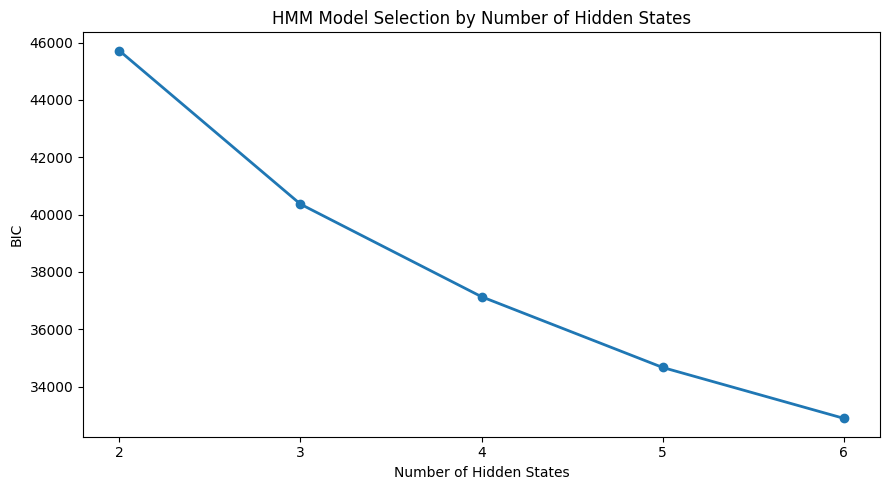

In [78]:
# Visualize BIC across candidate HMM specifications

fig_bic_selection, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    model_selection_df["States"],
    model_selection_df["BIC"],
    marker="o",
    linewidth=2
)

ax.set_title("HMM Model Selection by Number of Hidden States")
ax.set_xlabel("Number of Hidden States")
ax.set_ylabel("BIC")
ax.set_xticks(model_selection_df["States"])

ax.grid(False)

fig_bic_selection.tight_layout()
plt.show()

 BIC declines as additional hidden states are introduced, indicating improved statistical fit even after accounting for increasing model complexity. Among the specifications tested, the 6-state model produces the lowest BIC. The final regime count is therefore not selected from BIC alone; economic interpretability and parsimony are also considered.

### 3.1 Candidate State Diagnosis

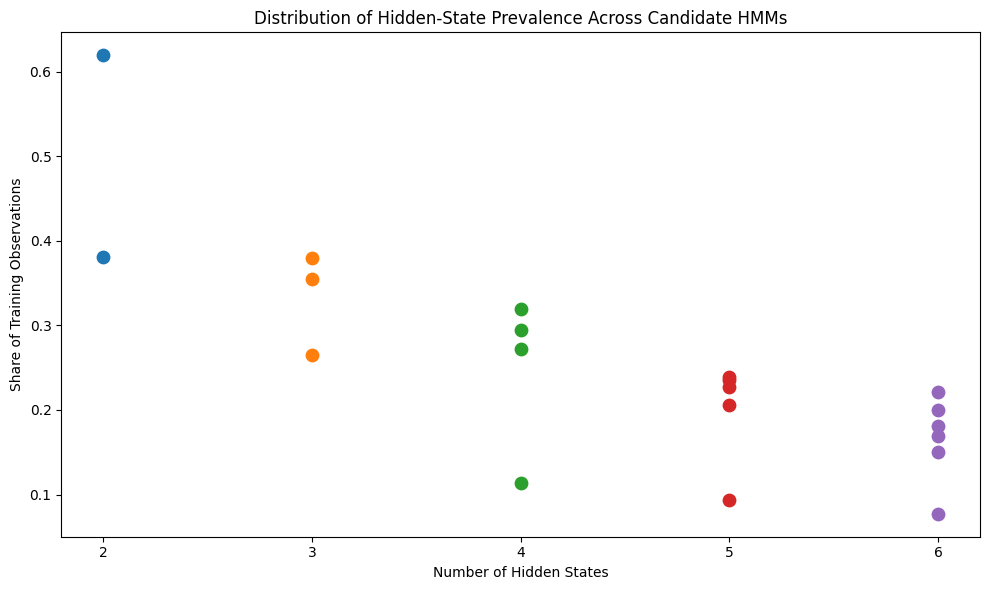

In [79]:
plot_prevalence = candidate_state_summary_df.copy()

fig_candidate_prevalence, ax = plt.subplots(
    figsize=(10, 6)
)

for k in sorted(plot_prevalence["States"].unique()):

    subset = plot_prevalence[
        plot_prevalence["States"] == k
    ]

    ax.scatter(
        [k] * len(subset),
        subset["Share"],
        s=80
    )

ax.set_title(
    "Distribution of Hidden-State Prevalence Across Candidate HMMs"
)
ax.set_xlabel("Number of Hidden States")
ax.set_ylabel("Share of Training Observations")
ax.set_xticks(
    sorted(plot_prevalence["States"].unique())
)

ax.grid(False)

fig_candidate_prevalence.tight_layout()
plt.show()

## 4. Final 3-State HMM Estimation

Based on the candidate-state evaluation, the **3-state specification** is retained for the main analysis.

Although models with more states achieve lower BIC values, the 3-state model provides a more parsimonious and economically interpretable representation of broad market conditions. Its hidden states correspond clearly to low-, intermediate-, and high-volatility environments, which align with the project's intended **Calm, Transition, and Stressed** regime framework.

The final HMM is estimated using the training period only. The fitted model is then used to infer hidden states for both the training and held-out test periods.

Because HMM state numbers are arbitrary, the raw states are subsequently mapped to economic regime labels based on their underlying market-risk characteristics.

In [80]:
# Final number of regimes
N_REGIMES = 3

# Use the best 3-state model identified during model selection
final_hmm = candidate_models[N_REGIMES]

print("Final HMM specification")
print("-----------------------")
print("Number of states:", final_hmm.n_components)
print("Covariance type:", final_hmm.covariance_type)
print("Converged:", final_hmm.monitor_.converged)
print(
    "Training log-likelihood:",
    round(final_hmm.score(X_train), 2)
)

Final HMM specification
-----------------------
Number of states: 3
Covariance type: full
Converged: True
Training log-likelihood: -19896.46


### 4.1 Hidden-State Assignment

The fitted HMM assigns each observation to the hidden state with the highest posterior probability.

State assignments are generated separately for:

- the training period used to estimate the HMM, and
- the held-out test period.

The numeric hidden-state labels produced by the model have no inherent economic meaning. For example, `State 0` is not automatically Calm and `State 2` is not automatically Stressed. Economic labels are therefore assigned in the next step using the characteristics of each hidden state.

In [81]:
# Predict hidden states

train_states = final_hmm.predict(X_train)
test_states = final_hmm.predict(X_test)

# Add raw state assignments to the corresponding datasets
train_results = train_df.copy()
test_results = test_df.copy()

train_results["HMM_State"] = train_states
test_results["HMM_State"] = test_states

print("Training observations:", len(train_results))
print("Test observations:", len(test_results))

print("\nTraining state counts:")
display(
    train_results["HMM_State"]
    .value_counts()
    .sort_index()
    .to_frame("Observations")
)

print("\nTest state counts:")
display(
    test_results["HMM_State"]
    .value_counts()
    .sort_index()
    .to_frame("Observations")
)

Training observations: 4508
Test observations: 2011

Training state counts:


,Observations
HMM_State,
0,1602
1,1193
2,1713



Test state counts:


,Observations
HMM_State,
0,619
1,404
2,988


### 4.2 Economic Interpretation of Hidden States

HMM state numbers are arbitrary and may change across model estimations. The hidden states are therefore labeled using their observed market characteristics rather than their numeric identifiers.

The primary ordering variables are:

1. **VIX Level**
2. **20-day Realized Volatility**

These variables provide the clearest measures of overall market stress.

States with the lowest volatility profile are classified as **Calm**, states with the highest volatility profile are classified as **Stressed**, and the remaining intermediate state is classified as **Transition**.

Skewness, kurtosis, and changes in the VIX are retained as additional descriptive characteristics of each regime.

In [82]:
# Calculate training-period characteristics of each hidden state

state_profiles = (
    train_results
    .groupby("HMM_State")
    .agg(
        Observations=("HMM_State", "size"),
        VIX_Level=("VIX_Level", "mean"),
        VIX_Change=("VIX_Change", "mean"),
        Realized_Vol_20D=("Realized_Vol_20D", "mean"),
        Return_Skew_20D=("Return_Skew_20D", "mean"),
        Return_Kurt_20D=("Return_Kurt_20D", "mean")
    )
)

state_profiles["Share"] = (
    state_profiles["Observations"] /
    len(train_results)
)

display(
    state_profiles.round(4)
)

,Observations,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D,Share
HMM_State,,,,,,,
0,1602,13.4101,-0.0058,0.0931,0.2008,0.3846,0.3554
1,1193,29.4197,-0.0066,0.2702,0.2846,0.3363,0.2646
2,1713,19.2329,0.0019,0.1549,-0.4937,0.6472,0.3800


In [83]:
# Rank states by overall volatility intensity

state_profiles["VIX_Rank"] = (
    state_profiles["VIX_Level"]
    .rank(method="dense")
)

state_profiles["RV_Rank"] = (
    state_profiles["Realized_Vol_20D"]
    .rank(method="dense")
)

state_profiles["Stress_Rank_Score"] = (
    state_profiles["VIX_Rank"]
    + state_profiles["RV_Rank"]
)

state_profiles = (
    state_profiles
    .sort_values("Stress_Rank_Score")
)

display(
    state_profiles.round(4)
)

,Observations,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D,Share,VIX_Rank,RV_Rank,Stress_Rank_Score
HMM_State,,,,,,,,,,
0,1602,13.4101,-0.0058,0.0931,0.2008,0.3846,0.3554,1.0,1.0,2.0
2,1713,19.2329,0.0019,0.1549,-0.4937,0.6472,0.3800,2.0,2.0,4.0
1,1193,29.4197,-0.0066,0.2702,0.2846,0.3363,0.2646,3.0,3.0,6.0


In [84]:
# Order states from lowest to highest market stress
ordered_states = (
    state_profiles
    .sort_values("Stress_Rank_Score")
    .index
    .tolist()
)

regime_mapping = {
    ordered_states[0]: "Calm",
    ordered_states[1]: "Transition",
    ordered_states[2]: "Stressed"
}

print("State-to-regime mapping:")
for state, regime in regime_mapping.items():
    print(f"State {state} -> {regime}")

State-to-regime mapping:
State 0 -> Calm
State 2 -> Transition
State 1 -> Stressed


In [85]:
# Apply economically interpreted regime labels

train_results["Regime"] = (
    train_results["HMM_State"]
    .map(regime_mapping)
)

test_results["Regime"] = (
    test_results["HMM_State"]
    .map(regime_mapping)
)

regime_order = [
    "Calm",
    "Transition",
    "Stressed"
]

train_results["Regime"] = pd.Categorical(
    train_results["Regime"],
    categories=regime_order,
    ordered=True
)

test_results["Regime"] = pd.Categorical(
    test_results["Regime"],
    categories=regime_order,
    ordered=True
)

In [86]:
# Verify training-period regime characteristics

train_regime_summary = (
    train_results
    .groupby(
        "Regime",
        observed=False
    )
    .agg(
        Observations=("Regime", "size"),
        VIX_Level=("VIX_Level", "mean"),
        Realized_Vol_20D=("Realized_Vol_20D", "mean"),
        VIX_Change=("VIX_Change", "mean"),
        Return_Skew_20D=("Return_Skew_20D", "mean"),
        Return_Kurt_20D=("Return_Kurt_20D", "mean")
    )
)

train_regime_summary["Share"] = (
    train_regime_summary["Observations"] /
    len(train_results)
)

display(
    train_regime_summary.round(4)
)

,Observations,VIX_Level,Realized_Vol_20D,VIX_Change,Return_Skew_20D,Return_Kurt_20D,Share
Regime,,,,,,,
Calm,1602,13.4101,0.0931,-0.0058,0.2008,0.3846,0.3554
Transition,1713,19.2329,0.1549,0.0019,-0.4937,0.6472,0.3800
Stressed,1193,29.4197,0.2702,-0.0066,0.2846,0.3363,0.2646


## Section Observation
### Final Regime Interpretation

The final 3-state HMM produces a clear economic ordering of market conditions.

- **Calm** periods exhibit the lowest VIX level and lowest 20-day realized volatility.
- **Transition** periods occupy an intermediate volatility environment and display more negative return skewness, suggesting greater downside asymmetry even before the most severe stress conditions emerge.
- **Stressed** periods exhibit substantially higher implied and realized volatility than the other two regimes.

The monotonic increase in both VIX and realized volatility from Calm to Transition to Stressed supports the economic interpretation assigned to the hidden states.

## Section 4 Visualizations

### Helper Functions:

In [87]:
# Calculate standardized average feature profile by HMM regime

profile_features = [
    "VIX_Level",
    "VIX_Change",
    "Realized_Vol_20D",
    "Return_Skew_20D",
    "Return_Kurt_20D"
]

# Use standardized training features
standardized_profile_df = pd.DataFrame(
    X_train,
    columns=profile_features,
    index=train_results.index
)

standardized_profile_df["Regime"] = (
    train_results["Regime"].astype(str).values
)

regime_feature_profiles = (
    standardized_profile_df
    .groupby("Regime")[profile_features]
    .mean()
    .reindex(["Calm", "Transition", "Stressed"])
)

display(regime_feature_profiles.round(3))

,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D
Regime,,,,,
Calm,-0.737,-0.002,-0.672,0.380,-0.062
Transition,-0.072,0.003,-0.082,-0.712,0.124
Stressed,1.092,-0.002,1.019,0.512,-0.096


In [88]:
# Helper Function
hmm_results = (
    pd.concat(
        [train_results, test_results],
        ignore_index=True
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

print(hmm_results.shape)
display(hmm_results.head())

(6519, 9)


,Date,SP500_Close,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D,HMM_State,Regime
0,2000-02-01,1409.280029,23.45,-1.50,0.263633,-0.523001,0.454056,2,Transition
1,2000-02-02,1409.119995,23.12,-0.33,0.223332,-0.218100,0.560588,2,Transition
2,2000-02-03,1424.969971,22.01,-1.11,0.226596,-0.291496,0.391489,2,Transition
3,2000-02-04,1424.369995,21.54,-0.47,0.226637,-0.275308,0.381911,2,Transition
4,2000-02-07,1424.239990,22.79,1.25,0.204786,-0.503579,0.804882,2,Transition


In [89]:
# Helper Function
regime_colors = {
    "Calm": "#6FAE7C",
    "Transition": "#D9A441",
    "Stressed": "#C65A5A"
}

### 4.2 Economic Interpretation of Hidden States

1) fig_regime_profiles

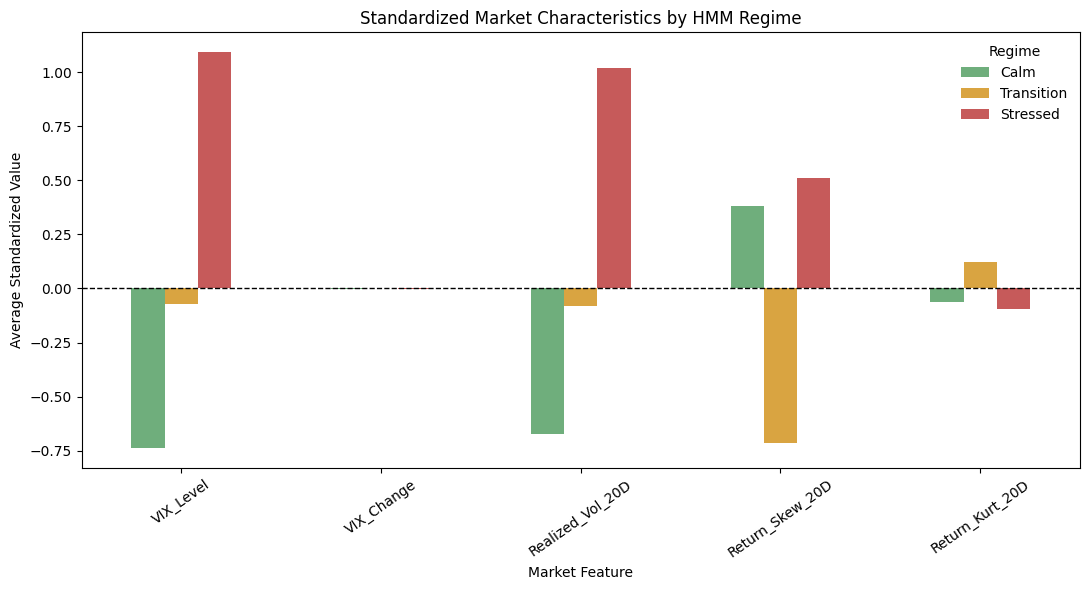

In [90]:
# Visualize standardized market characteristics by regime
fig_regime_profiles, ax = plt.subplots(
    figsize=(11, 6)
)

regime_feature_profiles.T.plot(
    kind="bar",
    ax=ax,
    color=[
        regime_colors["Calm"],
        regime_colors["Transition"],
        regime_colors["Stressed"]
    ]
)

ax.axhline(
    0,
    linewidth=1,
    linestyle="--",
    color="black"
)

ax.set_title(
    "Standardized Market Characteristics by HMM Regime"
)

ax.set_xlabel("Market Feature")
ax.set_ylabel("Average Standardized Value")

ax.tick_params(
    axis="x",
    rotation=35
)

ax.legend(
    title="Regime",
    frameon=False
)

ax.grid(False)

fig_regime_profiles.tight_layout()
plt.show()

2) fig_hmm_sp500_regimes

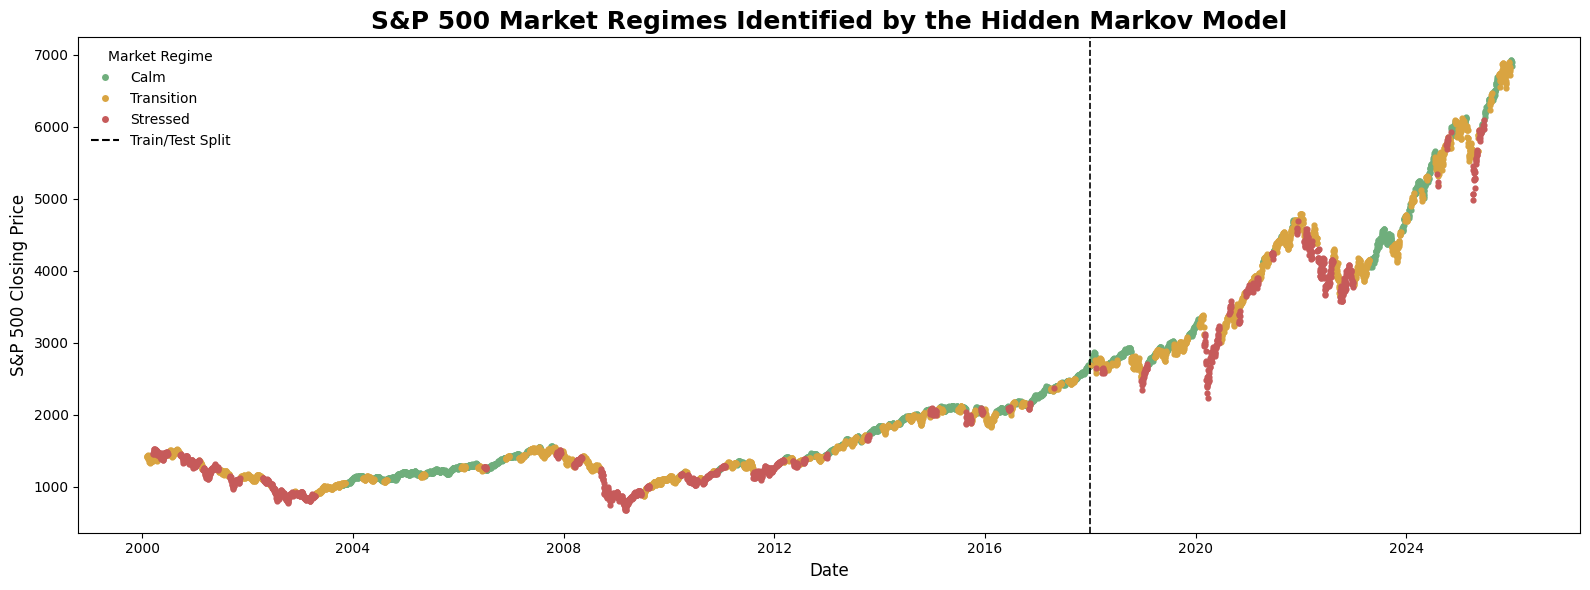

In [91]:
from matplotlib.lines import Line2D

fig_hmm_sp500_regimes, ax = plt.subplots(figsize=(16, 6))

# Scatter plot colored by regime
for regime in ["Calm", "Transition", "Stressed"]:
    subset = hmm_results[hmm_results["Regime"] == regime]

    ax.scatter(
        subset["Date"],
        subset["SP500_Close"],
        s=12,
        alpha=1.0,
        color=regime_colors[regime],
        label=regime
    )

# Train/test split
ax.axvline(
    pd.Timestamp("2018-01-01"),
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.set_title(
    "S&P 500 Market Regimes Identified by the Hidden Markov Model",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("S&P 500 Closing Price", fontsize=12)

ax.grid(False)

legend_items = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=regime_colors["Calm"], markersize=6, label='Calm'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=regime_colors["Transition"], markersize=6, label='Transition'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=regime_colors["Stressed"], markersize=6, label='Stressed'),
    Line2D([0], [0], linestyle='--', color='black', label='Train/Test Split')
]

ax.legend(
    handles=legend_items,
    title="Market Regime",
    loc="upper left",
    frameon=False
)

fig_hmm_sp500_regimes.tight_layout()
plt.show()

3) fig_hmm_vix_regimes

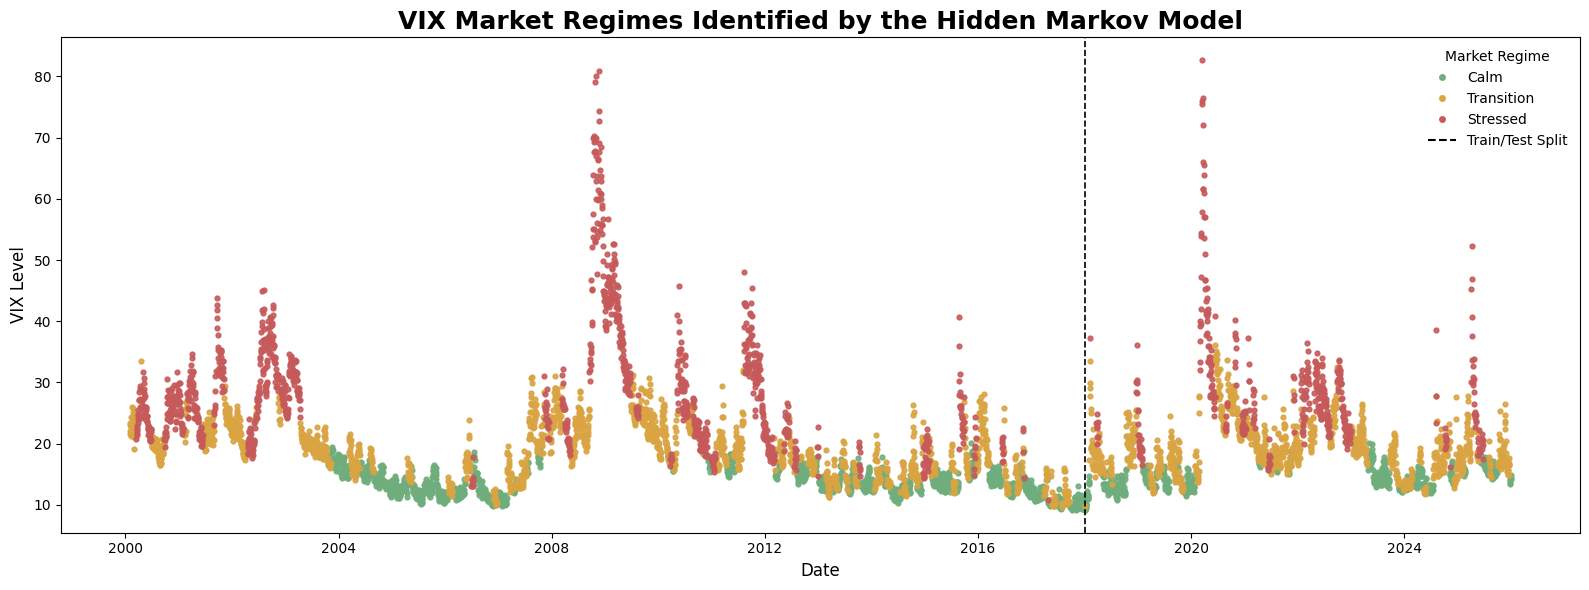

In [92]:
fig_hmm_vix_regimes, ax = plt.subplots(figsize=(16, 6))

# Scatter plot colored by regime
for regime in ["Calm", "Transition", "Stressed"]:
    subset = hmm_results[hmm_results["Regime"] == regime]

    ax.scatter(
        subset["Date"],
        subset["VIX_Level"],
        s=12,
        alpha=0.9,
        color=regime_colors[regime],
        label=regime
    )

# Train/test split
ax.axvline(
    pd.Timestamp("2018-01-01"),
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.set_title(
    "VIX Market Regimes Identified by the Hidden Markov Model",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("VIX Level", fontsize=12)

ax.grid(False)

legend_items_vix = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=regime_colors["Calm"], markersize=6, label='Calm'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=regime_colors["Transition"], markersize=6, label='Transition'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=regime_colors["Stressed"], markersize=6, label='Stressed'),
    Line2D([0], [0], linestyle='--', color='black', label='Train/Test Split')
]

ax.legend(
    handles=legend_items_vix,
    title="Market Regime",
    loc="upper right",
    frameon=False
)

fig_hmm_vix_regimes.tight_layout()
plt.show()

## 5. Train–Test Regime Stability

The HMM was estimated exclusively using observations from the 2000–2017 training period. The fitted model is now applied to the held-out 2018–2025 period without re-estimating its parameters.

This provides an out-of-sample assessment of whether the learned market-regime structure remains economically meaningful in later market environments.

The analysis compares:

- regime prevalence,
- average VIX levels,
- realized volatility,
- return skewness and kurtosis,
- and the ordering of Calm, Transition, and Stressed conditions

between the training and test periods.

In [93]:
test_regime_summary = (
    test_results
    .groupby(
        "Regime",
        observed=False
    )
    .agg(
        Observations=("Regime", "size"),
        VIX_Level=("VIX_Level", "mean"),
        Realized_Vol_20D=("Realized_Vol_20D", "mean"),
        VIX_Change=("VIX_Change", "mean"),
        Return_Skew_20D=("Return_Skew_20D", "mean"),
        Return_Kurt_20D=("Return_Kurt_20D", "mean")
    )
)

test_regime_summary["Share"] = (
    test_regime_summary["Observations"]
    / len(test_results)
)

display(
    test_regime_summary.round(4)
)

,Observations,VIX_Level,Realized_Vol_20D,VIX_Change,Return_Skew_20D,Return_Kurt_20D,Share
Regime,,,,,,,
Calm,619,14.2401,0.0964,-0.0014,0.0933,0.1115,0.3078
Transition,988,19.5088,0.1572,-0.0217,-0.5477,0.6514,0.4913
Stressed,404,28.8154,0.2829,0.0649,0.1699,0.6015,0.2009


In [94]:
train_compare = (
    train_regime_summary
    .reset_index()
    .assign(Period="Train")
)

test_compare = (
    test_regime_summary
    .reset_index()
    .assign(Period="Test")
)

regime_stability = pd.concat(
    [train_compare, test_compare],
    ignore_index=True
)

display(
    regime_stability[
        [
            "Period",
            "Regime",
            "Observations",
            "Share",
            "VIX_Level",
            "Realized_Vol_20D",
            "VIX_Change",
            "Return_Skew_20D",
            "Return_Kurt_20D"
        ]
    ].round(4)
)

,Period,Regime,Observations,Share,VIX_Level,Realized_Vol_20D,VIX_Change,Return_Skew_20D,Return_Kurt_20D
0,Train,Calm,1602,0.3554,13.4101,0.0931,-0.0058,0.2008,0.3846
1,Train,Transition,1713,0.3800,19.2329,0.1549,0.0019,-0.4937,0.6472
2,Train,Stressed,1193,0.2646,29.4197,0.2702,-0.0066,0.2846,0.3363
3,Test,Calm,619,0.3078,14.2401,0.0964,-0.0014,0.0933,0.1115
4,Test,Transition,988,0.4913,19.5088,0.1572,-0.0217,-0.5477,0.6514
5,Test,Stressed,404,0.2009,28.8154,0.2829,0.0649,0.1699,0.6015


## Section Observation
### Train–Test Regime Stability

The 3-state HMM retains a clear economic ordering when applied to the held-out 2018–2025 test period.

In both the training and test samples, average VIX levels and 20-day realized volatility increase monotonically from **Calm** to **Transition** to **Stressed**. This indicates that the regime definitions learned from the 2000–2017 training period remain meaningful when applied to previously unseen observations.

The absolute regime characteristics are also relatively similar across the two periods. For example, the average VIX level associated with the Stressed regime is approximately 29.4 in the training sample and 28.8 in the test sample.

Regime prevalence changes somewhat across periods. The test period contains a larger share of observations classified as Transition and smaller shares classified as Calm and Stressed. This indicates a change in the frequency of market conditions rather than a breakdown in the economic interpretation of the regimes.

Overall, the preservation of the volatility ordering across the held-out sample provides evidence that the estimated HMM regime structure generalizes reasonably well beyond the training period.

### Section 5 Visualizations

### 5.0 Train–Test Regime Stability

Helper Functions

In [95]:
train_compare = (
    train_regime_summary
    .reset_index()
    .assign(Period="Train")
)

test_compare = (
    test_regime_summary
    .reset_index()
    .assign(Period="Test")
)

regime_stability = pd.concat(
    [train_compare, test_compare],
    ignore_index=True
)

display(
    regime_stability[
        [
            "Period",
            "Regime",
            "Observations",
            "Share",
            "VIX_Level",
            "Realized_Vol_20D",
            "VIX_Change",
            "Return_Skew_20D",
            "Return_Kurt_20D"
        ]
    ].round(4)
)

,Period,Regime,Observations,Share,VIX_Level,Realized_Vol_20D,VIX_Change,Return_Skew_20D,Return_Kurt_20D
0,Train,Calm,1602,0.3554,13.4101,0.0931,-0.0058,0.2008,0.3846
1,Train,Transition,1713,0.3800,19.2329,0.1549,0.0019,-0.4937,0.6472
2,Train,Stressed,1193,0.2646,29.4197,0.2702,-0.0066,0.2846,0.3363
3,Test,Calm,619,0.3078,14.2401,0.0964,-0.0014,0.0933,0.1115
4,Test,Transition,988,0.4913,19.5088,0.1572,-0.0217,-0.5477,0.6514
5,Test,Stressed,404,0.2009,28.8154,0.2829,0.0649,0.1699,0.6015


1) fig_train_test_prevalance

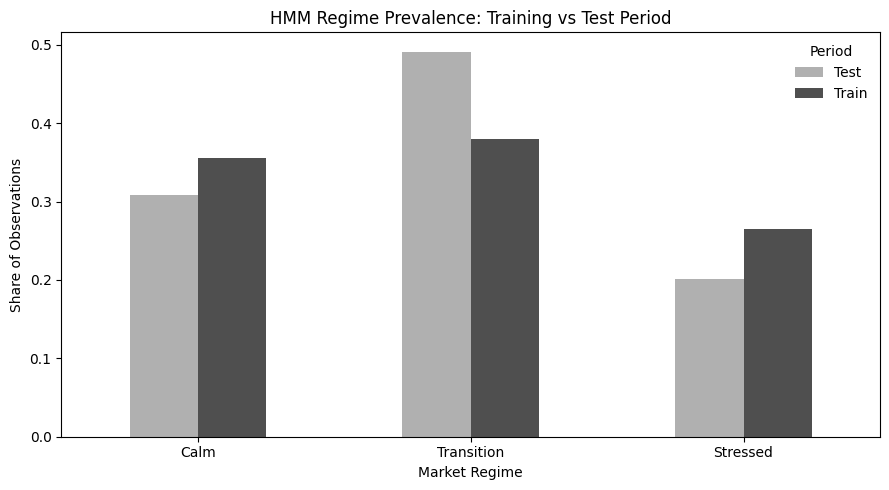

In [96]:
share_plot = (
    regime_stability[
        ["Period", "Regime", "Share"]
    ]
    .pivot(
        index="Regime",
        columns="Period",
        values="Share"
    )
    .reindex([
        "Calm",
        "Transition",
        "Stressed"
    ])
)

fig_train_test_prevalence, ax = plt.subplots(
    figsize=(9, 5)
)

share_plot.plot(
    kind="bar",
    ax=ax,
    color=[
        "#B0B0B0",
        "#4F4F4F"
    ]
)

ax.set_title(
    "HMM Regime Prevalence: Training vs Test Period"
)

ax.set_xlabel("Market Regime")
ax.set_ylabel("Share of Observations")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Period",
    frameon=False
)

ax.grid(False)

fig_train_test_prevalence.tight_layout()
plt.show()

2) fig_train_test_vix

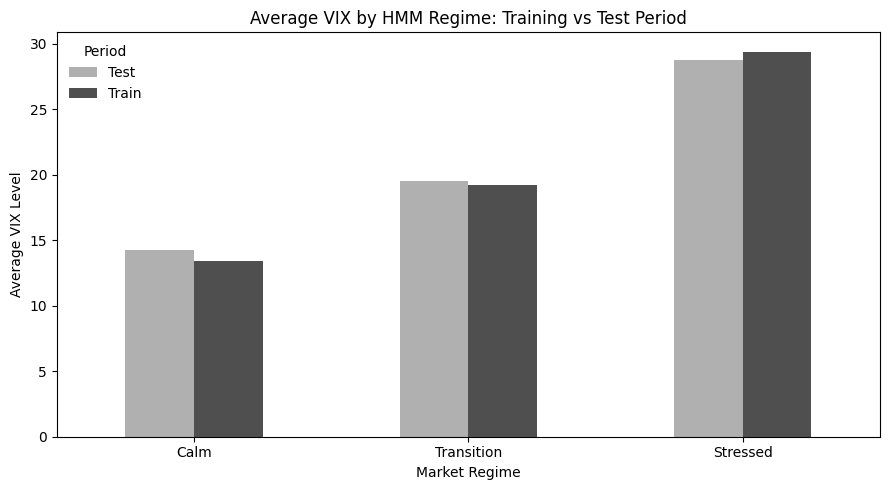

In [97]:
vix_comparison = (
    regime_stability[
        ["Period", "Regime", "VIX_Level"]
    ]
    .pivot(
        index="Regime",
        columns="Period",
        values="VIX_Level"
    )
    .reindex([
        "Calm",
        "Transition",
        "Stressed"
    ])
)

fig_train_test_vix, ax = plt.subplots(
    figsize=(9, 5)
)

vix_comparison.plot(
    kind="bar",
    ax=ax,
    color=[
        "#B0B0B0",
        "#4F4F4F"
    ]
)

ax.set_title(
    "Average VIX by HMM Regime: Training vs Test Period"
)

ax.set_xlabel("Market Regime")
ax.set_ylabel("Average VIX Level")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Period",
    frameon=False
)

ax.grid(False)

fig_train_test_vix.tight_layout()
plt.show()

## 6. HMM Transition Dynamics

The Hidden Markov Model explicitly estimates the probability of moving between market regimes over time.

The transition matrix summarizes the probability that the market remains in the same regime or moves to another regime on the next trading day.

Expected regime duration is also calculated from the probability of remaining in the same state. This provides a concise measure of regime persistence before moving to the K-means benchmark.

In [98]:
# Retrieve raw HMM transition matrix
transition_matrix = final_hmm.transmat_

# Reorder states into Calm → Transition → Stressed
ordered_raw_states = [
    state for regime in ["Calm", "Transition", "Stressed"]
    for state, label in regime_mapping.items()
    if label == regime
]

transition_df = pd.DataFrame(
    transition_matrix[
        np.ix_(ordered_raw_states, ordered_raw_states)
    ],
    index=["Calm", "Transition", "Stressed"],
    columns=["Calm", "Transition", "Stressed"]
)

display(
    transition_df.round(4)
)

,Calm,Transition,Stressed
Calm,0.9711,0.0240,0.0049
Transition,0.0221,0.9630,0.0149
Stressed,0.0075,0.0203,0.9722


In [99]:
expected_duration = pd.DataFrame({
    "Regime": transition_df.index,
    "Stay_Probability": np.diag(
        transition_df.values
    )
})

expected_duration["Expected_Duration_Days"] = (
    1 /
    (
        1 -
        expected_duration["Stay_Probability"]
    )
)

display(
    expected_duration.round(2)
)

,Regime,Stay_Probability,Expected_Duration_Days
0,Calm,0.97,34.56
1,Transition,0.96,27.03
2,Stressed,0.97,36.03


## Section Observation:
### HMM Transition Dynamics

## Section 6 Visualization


### 6.0 HMM Transition Dynamics

1) fig_hmm_transition_matrix

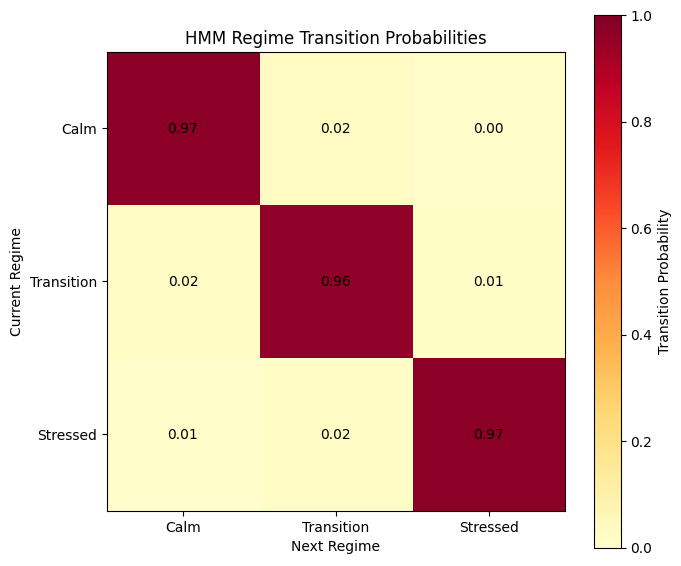

In [100]:
fig_hmm_transition_matrix, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(
    transition_df.values,
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)

# Axis labels
ax.set_xticks(range(len(transition_df.columns)))
ax.set_xticklabels(transition_df.columns)

ax.set_yticks(range(len(transition_df.index)))
ax.set_yticklabels(transition_df.index)

ax.set_xlabel("Next Regime")
ax.set_ylabel("Current Regime")

ax.set_title(
    "HMM Regime Transition Probabilities"
)

# Add probability labels inside cells
for i in range(transition_df.shape[0]):
    for j in range(transition_df.shape[1]):

        value = transition_df.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

# Remove gridlines
ax.grid(False)

# Colorbar
fig_hmm_transition_matrix.colorbar(
    im,
    ax=ax,
    label="Transition Probability"
)

fig_hmm_transition_matrix.tight_layout()
plt.show()

2) fig_hmm_expected_duration

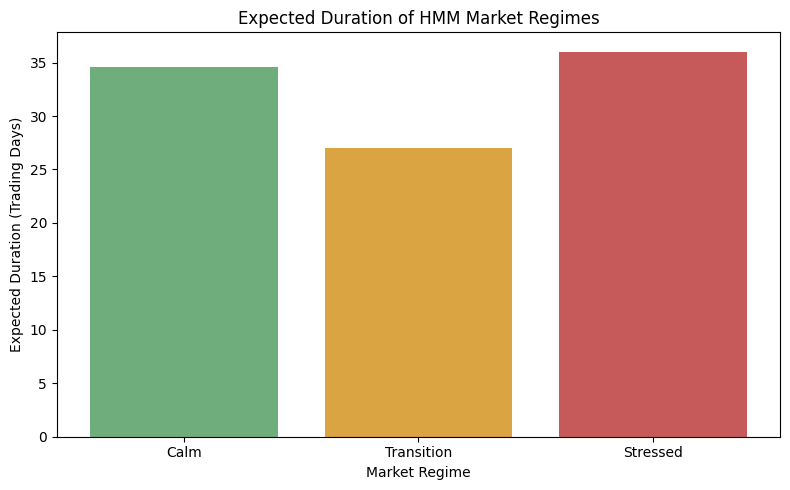

In [101]:
fig_hmm_expected_duration, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    expected_duration["Regime"],
    expected_duration["Expected_Duration_Days"],
    color=[
        regime_colors["Calm"],
        regime_colors["Transition"],
        regime_colors["Stressed"]
    ]
)

ax.set_title(
    "Expected Duration of HMM Market Regimes"
)

ax.set_xlabel("Market Regime")
ax.set_ylabel("Expected Duration (Trading Days)")

ax.grid(False)

fig_hmm_expected_duration.tight_layout()
plt.show()

## 7. K-Means Benchmark

K-means clustering is used as a simpler unsupervised benchmark against the Hidden Markov Model.

To ensure a fair comparison, K-means is trained using the same:

- five market-risk features,
- standardized training dataset,
- 2000–2017 training period,
- 2018–2025 test period,
- and three-regime specification.

Unlike the HMM, K-means treats each observation independently and does not model temporal persistence or transition probabilities.

The purpose of this benchmark is therefore to compare a purely feature-space clustering approach with the temporally structured HMM.

In [103]:
kmeans = KMeans(
    n_clusters=3,
    n_init=50,
    random_state=RANDOM_STATE
)

# Fit using training data only
kmeans.fit(X_train)

# Generate cluster assignments
kmeans_train_clusters = kmeans.predict(X_train)
kmeans_test_clusters = kmeans.predict(X_test)

# Store results
kmeans_train_results = train_df.copy()
kmeans_test_results = test_df.copy()

kmeans_train_results["KMeans_Cluster"] = kmeans_train_clusters
kmeans_test_results["KMeans_Cluster"] = kmeans_test_clusters

In [104]:
kmeans_profiles = (
    kmeans_train_results
    .groupby("KMeans_Cluster")
    .agg(
        Observations=("KMeans_Cluster", "size"),
        VIX_Level=("VIX_Level", "mean"),
        Realized_Vol_20D=("Realized_Vol_20D", "mean"),
        VIX_Change=("VIX_Change", "mean"),
        Return_Skew_20D=("Return_Skew_20D", "mean"),
        Return_Kurt_20D=("Return_Kurt_20D", "mean")
    )
)

kmeans_profiles["Share"] = (
    kmeans_profiles["Observations"]
    / len(kmeans_train_results)
)

display(
    kmeans_profiles.round(4)
)

,Observations,VIX_Level,Realized_Vol_20D,VIX_Change,Return_Skew_20D,Return_Kurt_20D,Share
KMeans_Cluster,,,,,,,
0,795,17.0614,0.1328,0.1623,-0.9112,2.0533,0.1764
1,2888,16.6912,0.1258,-0.0690,0.1575,0.1666,0.6406
2,825,33.6468,0.3246,0.0681,0.1031,0.0149,0.1830


In [105]:
kmeans_profiles["VIX_Rank"] = (
    kmeans_profiles["VIX_Level"]
    .rank(method="dense")
)

kmeans_profiles["RV_Rank"] = (
    kmeans_profiles["Realized_Vol_20D"]
    .rank(method="dense")
)

kmeans_profiles["Stress_Rank_Score"] = (
    kmeans_profiles["VIX_Rank"]
    + kmeans_profiles["RV_Rank"]
)

ordered_kmeans_clusters = (
    kmeans_profiles
    .sort_values("Stress_Rank_Score")
    .index
    .tolist()
)

kmeans_mapping = {
    ordered_kmeans_clusters[0]: "Calm",
    ordered_kmeans_clusters[1]: "Transition",
    ordered_kmeans_clusters[2]: "Stressed"
}

print("K-Means cluster mapping:")

for cluster, regime in kmeans_mapping.items():
    print(f"Cluster {cluster} -> {regime}")

K-Means cluster mapping:
Cluster 1 -> Calm
Cluster 0 -> Transition
Cluster 2 -> Stressed


In [107]:
kmeans_train_results["Regime"] = (
    kmeans_train_results["KMeans_Cluster"]
    .map(kmeans_mapping)
)

kmeans_test_results["Regime"] = (
    kmeans_test_results["KMeans_Cluster"]
    .map(kmeans_mapping)
)

kmeans_train_results["Regime"] = pd.Categorical(
    kmeans_train_results["Regime"],
    categories=["Calm", "Transition", "Stressed"],
    ordered=True
)

kmeans_test_results["Regime"] = pd.Categorical(
    kmeans_test_results["Regime"],
    categories=["Calm", "Transition", "Stressed"],
    ordered=True
)

In [108]:
kmeans_regime_summary = (
    kmeans_train_results
    .groupby(
        "Regime",
        observed=False
    )
    .agg(
        Observations=("Regime", "size"),
        VIX_Level=("VIX_Level", "mean"),
        Realized_Vol_20D=("Realized_Vol_20D", "mean"),
        VIX_Change=("VIX_Change", "mean"),
        Return_Skew_20D=("Return_Skew_20D", "mean"),
        Return_Kurt_20D=("Return_Kurt_20D", "mean")
    )
)

kmeans_regime_summary["Share"] = (
    kmeans_regime_summary["Observations"]
    / len(kmeans_train_results)
)

display(
    kmeans_regime_summary.round(4)
)

,Observations,VIX_Level,Realized_Vol_20D,VIX_Change,Return_Skew_20D,Return_Kurt_20D,Share
Regime,,,,,,,
Calm,2888,16.6912,0.1258,-0.0690,0.1575,0.1666,0.6406
Transition,795,17.0614,0.1328,0.1623,-0.9112,2.0533,0.1764
Stressed,825,33.6468,0.3246,0.0681,0.1031,0.0149,0.1830


In [109]:
kmeans_standardized_df = pd.DataFrame(
    X_train,
    columns=profile_features,
    index=kmeans_train_results.index
)

kmeans_standardized_df["Regime"] = (
    kmeans_train_results["Regime"]
    .astype(str)
    .values
)

kmeans_feature_profiles = (
    kmeans_standardized_df
    .groupby("Regime")[profile_features]
    .mean()
    .reindex([
        "Calm",
        "Transition",
        "Stressed"
    ])
)

## Section Observation
### K-Means Regime Interpretation

The K-means solution identifies three economically distinguishable groups, although their structure differs from the HMM regimes.

The **Calm** cluster contains approximately 64% of the training observations and is characterized by relatively low VIX and realized volatility.

The **Stressed** cluster is clearly distinguished by substantially higher implied and realized volatility, with an average VIX of approximately 33.6 and 20-day realized volatility of approximately 0.325.

The **Transition** cluster differs from both groups primarily through the shape of the return distribution rather than through volatility levels alone. Its average VIX and realized volatility remain relatively close to the Calm cluster, but it exhibits a positive average change in the VIX, strongly negative return skewness, and substantially elevated kurtosis.

This indicates that K-means identifies a distinct group of observations associated with greater downside asymmetry and tail risk even when the overall volatility level has not yet reached the Stressed regime.

Compared with the HMM, K-means also produces a considerably larger Calm cluster and smaller Transition and Stressed clusters. This difference will be examined further in the model benchmarking section.

## Section 7 Visualization
### 7.0 K-Means Benchmark

Helper function

In [111]:
kmeans_results = (
    pd.concat(
        [
            kmeans_train_results,
            kmeans_test_results
        ],
        ignore_index=True
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

1) fig_kmeans_regime_profiles

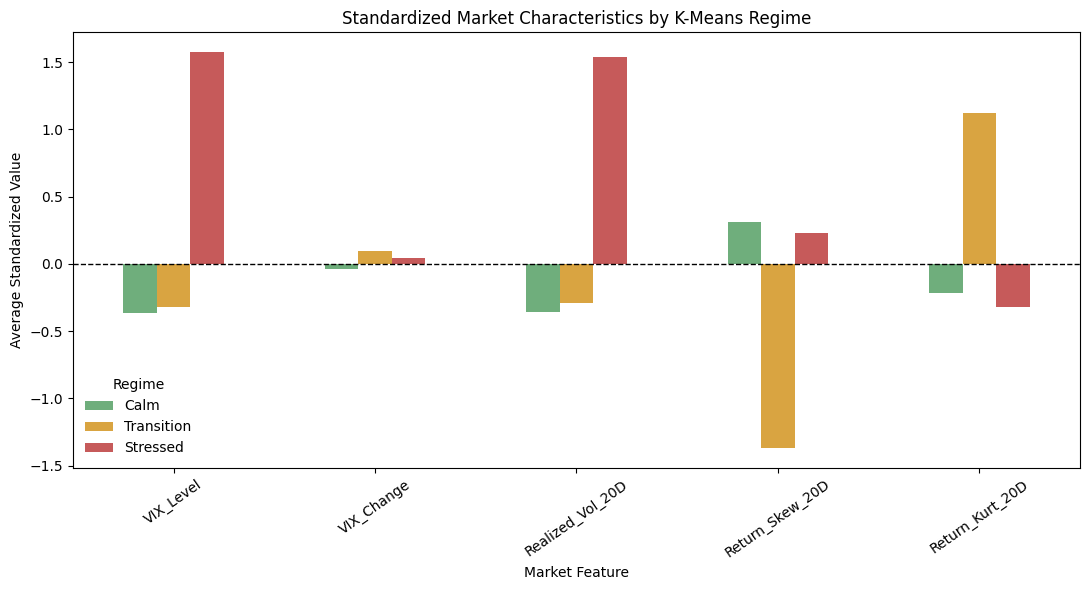

In [110]:
fig_kmeans_regime_profiles, ax = plt.subplots(
    figsize=(11, 6)
)

kmeans_feature_profiles.T.plot(
    kind="bar",
    ax=ax,
    color=[
        regime_colors["Calm"],
        regime_colors["Transition"],
        regime_colors["Stressed"]
    ]
)

ax.axhline(
    0,
    linewidth=1,
    linestyle="--",
    color="black"
)

ax.set_title(
    "Standardized Market Characteristics by K-Means Regime"
)

ax.set_xlabel("Market Feature")
ax.set_ylabel("Average Standardized Value")

ax.tick_params(
    axis="x",
    rotation=35
)

ax.legend(
    title="Regime",
    frameon=False
)

ax.grid(False)

fig_kmeans_regime_profiles.tight_layout()
plt.show()

2) fig_kmeans_sp500_regimes

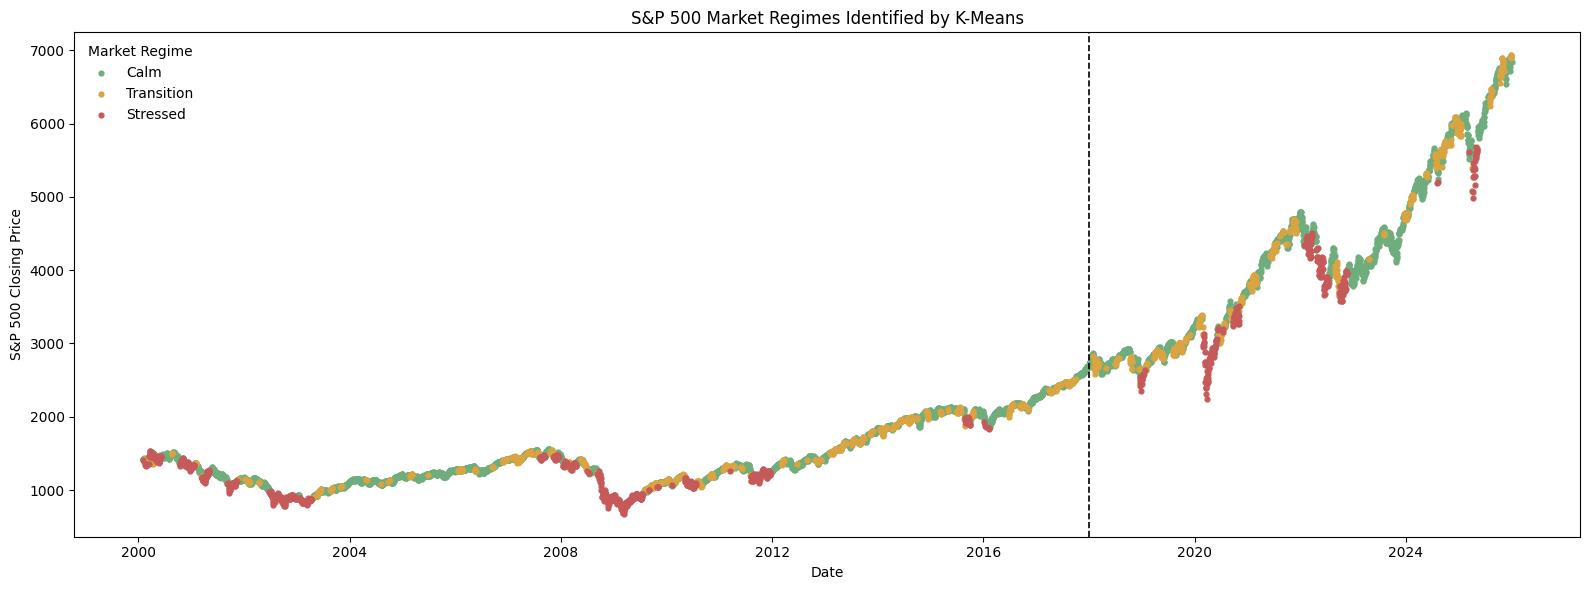

In [112]:
fig_kmeans_sp500_regimes, ax = plt.subplots(
    figsize=(16, 6)
)

for regime in ["Calm", "Transition", "Stressed"]:

    subset = kmeans_results[
        kmeans_results["Regime"] == regime
    ]

    ax.scatter(
        subset["Date"],
        subset["SP500_Close"],
        s=12,
        alpha=1.0,
        color=regime_colors[regime],
        label=regime
    )

ax.axvline(
    pd.Timestamp("2018-01-01"),
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.set_title(
    "S&P 500 Market Regimes Identified by K-Means"
)

ax.set_xlabel("Date")
ax.set_ylabel("S&P 500 Closing Price")

ax.legend(
    title="Market Regime",
    frameon=False
)

ax.grid(False)

fig_kmeans_sp500_regimes.tight_layout()
plt.show()

3) fig_kmeans_vix_regimes

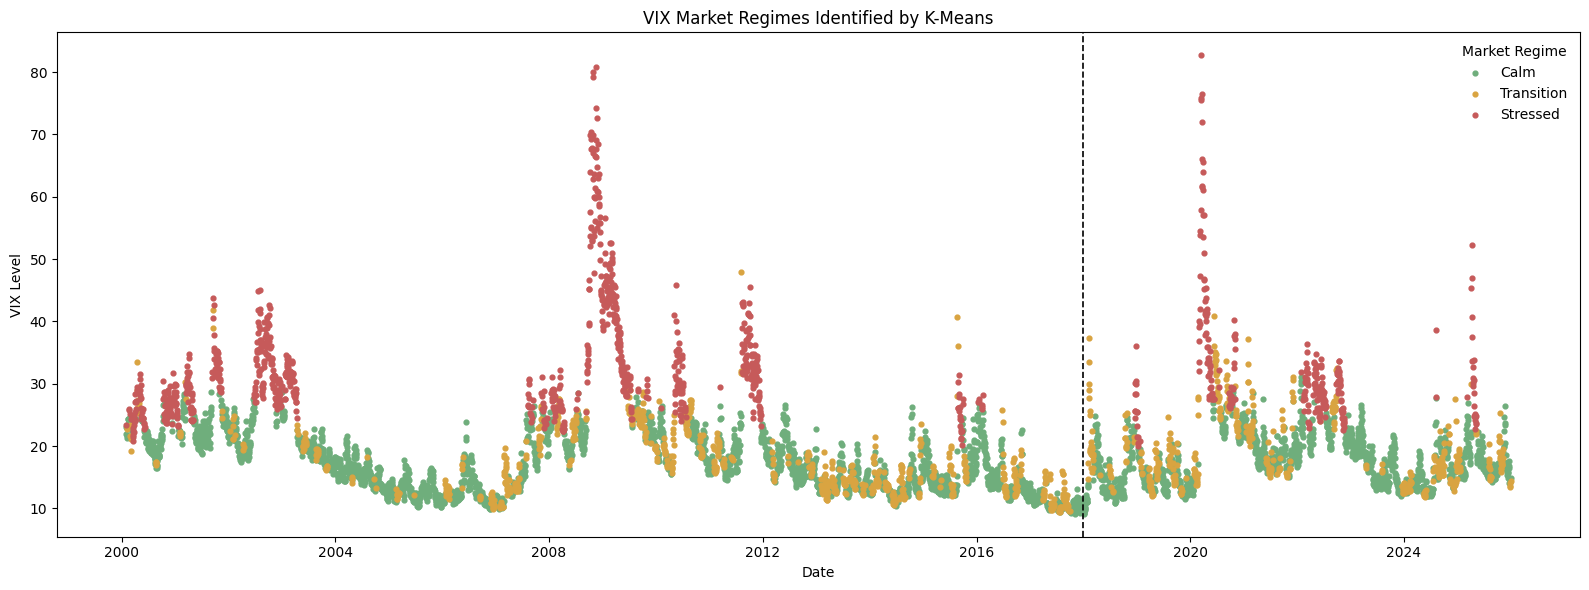

In [113]:
fig_kmeans_vix_regimes, ax = plt.subplots(
    figsize=(16, 6)
)

for regime in ["Calm", "Transition", "Stressed"]:

    subset = kmeans_results[
        kmeans_results["Regime"] == regime
    ]

    ax.scatter(
        subset["Date"],
        subset["VIX_Level"],
        s=12,
        alpha=1.0,
        color=regime_colors[regime],
        label=regime
    )

ax.axvline(
    pd.Timestamp("2018-01-01"),
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.set_title(
    "VIX Market Regimes Identified by K-Means"
)

ax.set_xlabel("Date")
ax.set_ylabel("VIX Level")

ax.legend(
    title="Market Regime",
    frameon=False
)

ax.grid(False)

fig_kmeans_vix_regimes.tight_layout()
plt.show()

## 8. HMM vs. K-Means Benchmarking

The HMM and K-means solutions are compared using complementary metrics.

The **Silhouette Score**, **Davies-Bouldin Index**, and **Calinski-Harabasz Score** evaluate how well separated the identified groups are in the standardized feature space.

The **Adjusted Rand Index (ARI)** measures agreement between the HMM and K-means assignments, independent of their numeric cluster labels.

Because the HMM explicitly models temporal dependence while K-means does not, the models are also compared using **regime-switching frequency**. This provides a measure of how persistent or fragmented the resulting market regimes are over time.

In [114]:
# Training-period labels
hmm_train_labels = (
    train_results["HMM_State"]
    .to_numpy()
)

kmeans_train_labels = (
    kmeans_train_results["KMeans_Cluster"]
    .to_numpy()
)

# Benchmark metrics
benchmark_metrics = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ],
    "HMM": [
        silhouette_score(
            X_train,
            hmm_train_labels
        ),
        davies_bouldin_score(
            X_train,
            hmm_train_labels
        ),
        calinski_harabasz_score(
            X_train,
            hmm_train_labels
        )
    ],
    "K-Means": [
        silhouette_score(
            X_train,
            kmeans_train_labels
        ),
        davies_bouldin_score(
            X_train,
            kmeans_train_labels
        ),
        calinski_harabasz_score(
            X_train,
            kmeans_train_labels
        )
    ]
})

display(
    benchmark_metrics.round(4)
)

,Metric,HMM,K-Means
0,Silhouette Score,0.1232,0.2737
1,Davies-Bouldin Index,1.8834,1.3083
2,Calinski-Harabasz Score,767.9406,1227.0183


In [115]:
ari_train = adjusted_rand_score(
    hmm_train_labels,
    kmeans_train_labels
)

print(
    "Adjusted Rand Index (HMM vs. K-Means):",
    round(ari_train, 4)
)

Adjusted Rand Index (HMM vs. K-Means): 0.2226


In [116]:
def switching_statistics(labels):
    """
    Calculate the number and frequency of changes
    between consecutive regime assignments.
    """
    labels = np.asarray(labels)

    switches = np.sum(
        labels[1:] != labels[:-1]
    )

    switch_rate = (
        switches / (len(labels) - 1)
    )

    return switches, switch_rate

In [117]:
hmm_switches, hmm_switch_rate = switching_statistics(
    train_results["Regime"]
)

kmeans_switches, kmeans_switch_rate = switching_statistics(
    kmeans_train_results["Regime"]
)

switching_comparison = pd.DataFrame({
    "Model": [
        "HMM",
        "K-Means"
    ],
    "Regime_Switches": [
        hmm_switches,
        kmeans_switches
    ],
    "Switch_Rate": [
        hmm_switch_rate,
        kmeans_switch_rate
    ]
})

display(
    switching_comparison.round(4)
)

,Model,Regime_Switches,Switch_Rate
0,HMM,131,0.0291
1,K-Means,368,0.0817


### 8.1 Historical Stress-Period Validation

To evaluate the economic relevance of the identified regimes, the HMM and K-means classifications are examined during two major historical periods of market distress:

- **Global Financial Crisis (GFC): August 2007 – June 2009**
- **COVID-19 Market Shock: February 2020 – June 2020**

The Global Financial Crisis falls within the HMM training period, while the COVID-19 shock occurs entirely within the held-out test period. COVID therefore provides an especially useful out-of-sample assessment of whether the regime structure learned from earlier market data identifies a later episode of extreme stress.

For each event, the analysis compares:

- the share of observations classified as Calm, Transition, and Stressed;
- the number of regime switches;
- and the timing of the regime classifications relative to the market decline.

The purpose is not to treat historical events as formal ground-truth labels, but to assess whether the unsupervised regimes exhibit economically plausible behavior during well-known periods of market disruption.

In [133]:
# define stress periods
stress_periods = {
    "Global Financial Crisis": {
        "start": "2007-08-01",
        "end": "2009-06-30"
    },
    "COVID-19 Shock": {
        "start": "2020-02-19",
        "end": "2020-06-30"
    }
}

In [134]:
# Compare regime classification during each event
stress_results = []

for event, dates in stress_periods.items():

    start = pd.Timestamp(dates["start"])
    end = pd.Timestamp(dates["end"])

    # HMM event sample
    hmm_event = hmm_results[
        hmm_results["Date"].between(start, end)
    ].copy()

    # K-Means event sample
    km_event = kmeans_results[
        kmeans_results["Date"].between(start, end)
    ].copy()

    for model_name, event_df in [
        ("HMM", hmm_event),
        ("K-Means", km_event)
    ]:

        shares = (
            event_df["Regime"]
            .value_counts(normalize=True)
        )

        switches = (
            event_df["Regime"]
            .astype(str)
            .ne(
                event_df["Regime"]
                .astype(str)
                .shift()
            )
            .sum() - 1
        )

        stress_results.append({
            "Event": event,
            "Model": model_name,
            "Observations": len(event_df),
            "Calm_Share": shares.get("Calm", 0),
            "Transition_Share": shares.get("Transition", 0),
            "Stressed_Share": shares.get("Stressed", 0),
            "Regime_Switches": switches
        })

stress_validation = pd.DataFrame(
    stress_results
)

display(
    stress_validation.round(4)
)

,Event,Model,Observations,Calm_Share,Transition_Share,Stressed_Share,Regime_Switches
0,Global Financial Crisis,HMM,483,0.0290,0.4431,0.5280,8
1,Global Financial Crisis,K-Means,483,0.3106,0.1222,0.5673,44
2,COVID-19 Shock,HMM,93,0.0000,0.2043,0.7957,2
3,COVID-19 Shock,K-Means,93,0.0645,0.2043,0.7312,6


In [135]:
# comparing when both models entered first stress period
first_stressed_results = []

for event, dates in stress_periods.items():

    start = pd.Timestamp(dates["start"])
    end = pd.Timestamp(dates["end"])

    for model_name, results_df in [
        ("HMM", hmm_results),
        ("K-Means", kmeans_results)
    ]:

        event_df = results_df[
            results_df["Date"].between(
                start,
                end
            )
        ]

        stressed_dates = event_df.loc[
            event_df["Regime"] == "Stressed",
            "Date"
        ]

        first_stressed = (
            stressed_dates.min()
            if not stressed_dates.empty
            else pd.NaT
        )

        first_stressed_results.append({
            "Event": event,
            "Model": model_name,
            "First_Stressed_Date": first_stressed
        })

first_stressed_df = pd.DataFrame(
    first_stressed_results
)

display(first_stressed_df)

,Event,Model,First_Stressed_Date
0,Global Financial Crisis,HMM,2007-11-12
1,Global Financial Crisis,K-Means,2007-08-09
2,COVID-19 Shock,HMM,2020-02-27
3,COVID-19 Shock,K-Means,2020-02-27


## Section Observation
### HMM vs. K-Means Benchmarking

### 1) HMM–K-Means Agreement

The Adjusted Rand Index between the HMM and K-means assignments is **0.223**, indicating relatively limited agreement between the two clustering solutions.

This suggests that the two methods identify meaningfully different partitions of the market data rather than simply relabeling similar groups.

The difference is consistent with the modeling assumptions of each approach. K-means groups observations according to similarity in the standardized feature space, whereas the HMM also incorporates temporal dependence and regime persistence.

The disagreement appears particularly plausible around the Transition regime, which the two models characterize differently. In the HMM, Transition represents an intermediate-volatility state, while in K-means it is more strongly associated with negative skewness and elevated kurtosis.

### 2) Temporal Switching Comparison

The HMM produces substantially more persistent regime classifications than K-means.

Across the training period, the HMM changes regime 131 times, corresponding to a switching rate of approximately 2.9%. K-means changes regime 368 times, with a switching rate of approximately 8.2%.

This indicates that the K-means solution is considerably more fragmented through time, while the HMM generates smoother and more persistent regime sequences.

The result is consistent with the underlying model structures: K-means assigns each observation independently according to feature-space similarity, whereas the HMM explicitly incorporates transition probabilities and temporal persistence between latent states.

### 3) Historical Stress-Period Results

Both unsupervised models identify the Global Financial Crisis and COVID-19 shock as periods dominated by elevated or stressed market conditions, but their temporal behavior differs substantially.

During the **Global Financial Crisis**, the HMM classifies approximately 52.8% of observations as Stressed and 44.3% as Transition, with only 2.9% assigned to Calm. K-means assigns a similar proportion of observations to the Stressed regime (56.7%) but classifies a substantially larger share as Calm (31.1%). The K-means solution also changes regime 44 times during the event window, compared with only 8 switches for the HMM.

During the **COVID-19 market shock**, the HMM identifies an even more concentrated stress episode. Approximately 79.6% of observations are classified as Stressed, 20.4% as Transition, and none as Calm. K-means similarly identifies the period as predominantly Stressed, with 73.1% of observations assigned to that regime, but also classifies 6.5% of observations as Calm.

The difference in switching behavior is again notable: the HMM changes regime only twice during the COVID window, compared with six changes under K-means.

These results suggest that both methods capture major periods of market distress, while the HMM produces more persistent regime sequences and fewer temporary reversals to Calm conditions. This is consistent with the HMM's explicit modeling of temporal dependence and transition probabilities.

## Section 8 Visualization
### HMM vs. K-Means Benchmarking




Helper Function

In [119]:
agreement_table = pd.crosstab(
    train_results["Regime"],
    kmeans_train_results["Regime"],
    normalize="index"
)

agreement_table = (
    agreement_table
    .reindex(
        index=[
            "Calm",
            "Transition",
            "Stressed"
        ],
        columns=[
            "Calm",
            "Transition",
            "Stressed"
        ]
    )
)

display(
    agreement_table.round(3)
)

Regime,Calm,Transition,Stressed
Regime,,,
Calm,0.947,0.053,0.000
Transition,0.550,0.400,0.050
Stressed,0.360,0.021,0.619


In [137]:
gfc_start = pd.Timestamp("2007-08-01")
gfc_end = pd.Timestamp("2009-06-30")

hmm_gfc = hmm_results[
    hmm_results["Date"].between(
        gfc_start,
        gfc_end
    )
]

km_gfc = kmeans_results[
    kmeans_results["Date"].between(
        gfc_start,
        gfc_end
    )
]

In [138]:
covid_start = pd.Timestamp("2020-02-19")
covid_end = pd.Timestamp("2020-06-30")

hmm_covid = hmm_results[
    hmm_results["Date"].between(
        covid_start,
        covid_end
    )
]

km_covid = kmeans_results[
    kmeans_results["Date"].between(
        covid_start,
        covid_end
    )
]

1) fig_switching_comparison

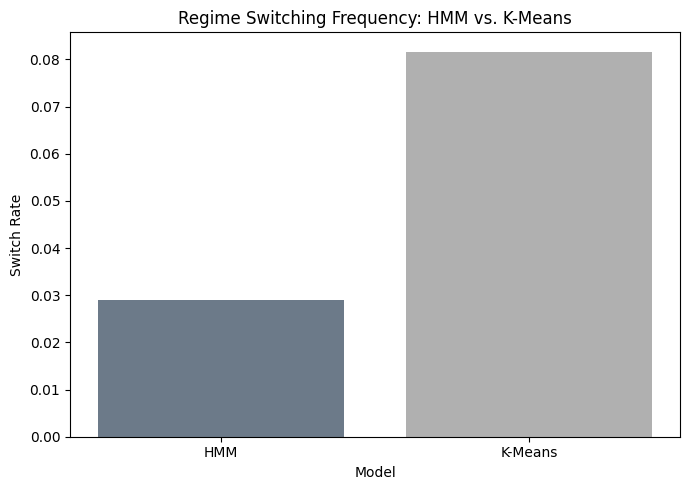

In [118]:
fig_switching_comparison, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    switching_comparison["Model"],
    switching_comparison["Switch_Rate"],
    color=["#6C7A89", "#B0B0B0"]
)

ax.set_title(
    "Regime Switching Frequency: HMM vs. K-Means"
)

ax.set_xlabel("Model")
ax.set_ylabel("Switch Rate")

ax.grid(False)

fig_switching_comparison.tight_layout()
plt.show()

2) fig_hmm_kmeans_agreement

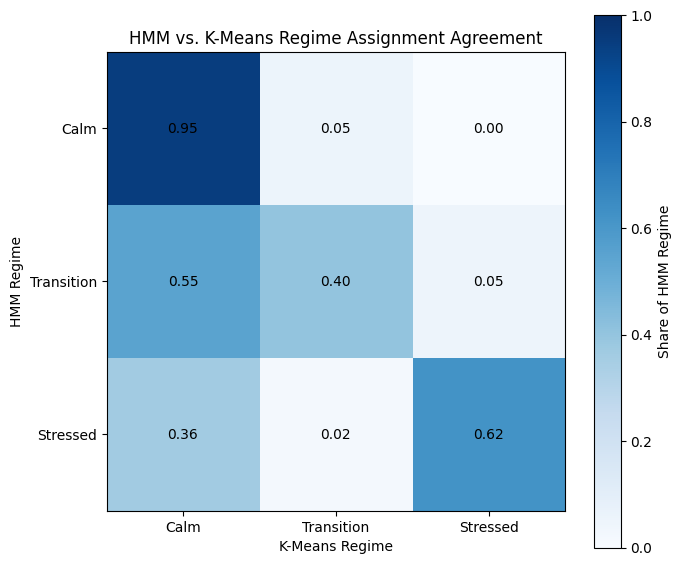

In [120]:
fig_hmm_kmeans_agreement, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(
    agreement_table.values,
    cmap="Blues",
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(agreement_table.columns))
)

ax.set_xticklabels(
    agreement_table.columns
)

ax.set_yticks(
    range(len(agreement_table.index))
)

ax.set_yticklabels(
    agreement_table.index
)

ax.set_xlabel(
    "K-Means Regime"
)

ax.set_ylabel(
    "HMM Regime"
)

ax.set_title(
    "HMM vs. K-Means Regime Assignment Agreement"
)

for i in range(agreement_table.shape[0]):
    for j in range(agreement_table.shape[1]):

        value = agreement_table.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

ax.grid(False)

fig_hmm_kmeans_agreement.colorbar(
    im,
    ax=ax,
    label="Share of HMM Regime"
)

fig_hmm_kmeans_agreement.tight_layout()
plt.show()

### Historical Stress-Period Validation




1) fig_gfc_model_comparison

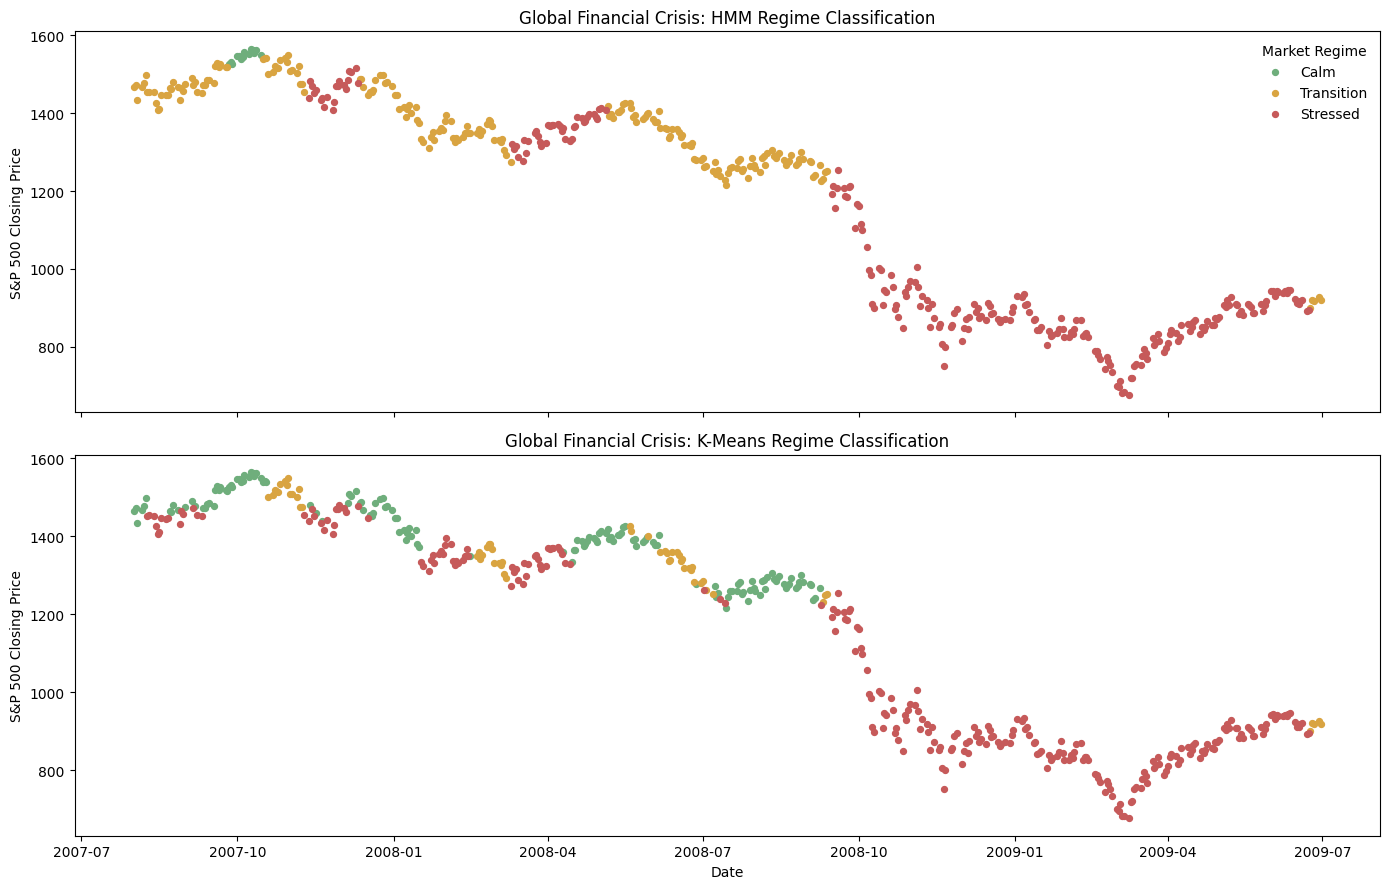

In [139]:
fig_gfc_model_comparison, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

# -------------------
# HMM
# -------------------

for regime in [
    "Calm",
    "Transition",
    "Stressed"
]:

    subset = hmm_gfc[
        hmm_gfc["Regime"] == regime
    ]

    axes[0].scatter(
        subset["Date"],
        subset["SP500_Close"],
        s=18,
        color=regime_colors[regime],
        alpha=1.0,
        label=regime
    )

axes[0].set_title(
    "Global Financial Crisis: HMM Regime Classification"
)

axes[0].set_ylabel(
    "S&P 500 Closing Price"
)

axes[0].legend(
    title="Market Regime",
    frameon=False
)

axes[0].grid(False)


# -------------------
# K-Means
# -------------------

for regime in [
    "Calm",
    "Transition",
    "Stressed"
]:

    subset = km_gfc[
        km_gfc["Regime"] == regime
    ]

    axes[1].scatter(
        subset["Date"],
        subset["SP500_Close"],
        s=18,
        color=regime_colors[regime],
        alpha=1.0
    )

axes[1].set_title(
    "Global Financial Crisis: K-Means Regime Classification"
)

axes[1].set_xlabel("Date")

axes[1].set_ylabel(
    "S&P 500 Closing Price"
)

axes[1].grid(False)

fig_gfc_model_comparison.tight_layout()

plt.show()

2) fig_covid_model_comparison

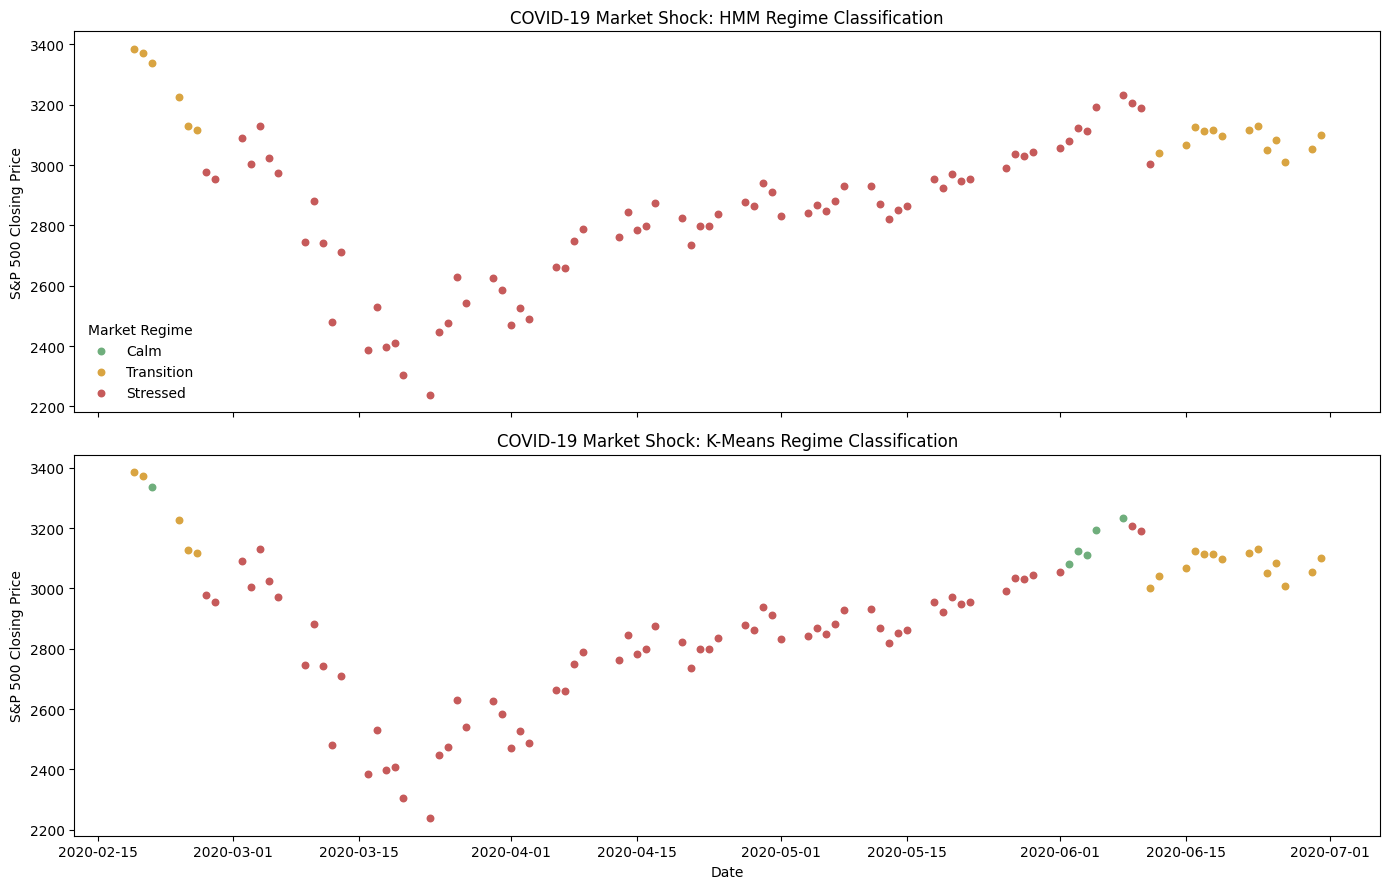

In [140]:
fig_covid_model_comparison, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

# -------------------
# HMM
# -------------------

for regime in [
    "Calm",
    "Transition",
    "Stressed"
]:

    subset = hmm_covid[
        hmm_covid["Regime"] == regime
    ]

    axes[0].scatter(
        subset["Date"],
        subset["SP500_Close"],
        s=22,
        color=regime_colors[regime],
        alpha=1.0,
        label=regime
    )

axes[0].set_title(
    "COVID-19 Market Shock: HMM Regime Classification"
)

axes[0].set_ylabel(
    "S&P 500 Closing Price"
)

axes[0].legend(
    title="Market Regime",
    frameon=False
)

axes[0].grid(False)


# -------------------
# K-Means
# -------------------

for regime in [
    "Calm",
    "Transition",
    "Stressed"
]:

    subset = km_covid[
        km_covid["Regime"] == regime
    ]

    axes[1].scatter(
        subset["Date"],
        subset["SP500_Close"],
        s=22,
        color=regime_colors[regime],
        alpha=1.0
    )

axes[1].set_title(
    "COVID-19 Market Shock: K-Means Regime Classification"
)

axes[1].set_xlabel("Date")

axes[1].set_ylabel(
    "S&P 500 Closing Price"
)

axes[1].grid(False)

fig_covid_model_comparison.tight_layout()

plt.show()

## 9. Final Model Outputs for Supervised Learning

The final stage of Model B converts the HMM results into a structured set of regime features that can be used in the supervised learning component of the project.

For each observation, the fitted HMM produces both a discrete regime assignment and a set of posterior probabilities indicating the probability that the observation belongs to each latent market state. These probabilities provide more information than the regime label alone because they capture the model's degree of certainty and the relative likelihood of alternative states.

The raw HMM states are mapped to the economically interpreted regimes **Calm**, **Transition**, and **Stressed**. The corresponding posterior probabilities are stored as:

- `P_Calm`
- `P_Transition`
- `P_Stressed`

A **Regime Confidence** measure is also calculated as the maximum posterior probability across the three regimes for each observation. This provides a simple measure of how decisively the HMM classifies each trading day.

The resulting regime information is prepared for use in **Model A**, where the regime label and posterior probabilities can be incorporated alongside market variables as predictors of forward realized volatility. Using the posterior probabilities allows the supervised model to capture gradual or uncertain transitions between market states rather than relying only on a single categorical regime assignment.

Two outputs are saved from this notebook:

1. A compact regime-feature dataset containing the date, HMM state, economic regime label, posterior regime probabilities, and regime confidence for use in the supervised model.
2. A full analytical dataset containing the original market features together with the HMM regime outputs for further analysis and validation.

These outputs complete the unsupervised learning stage and provide the link between **market-regime identification in Model B** and **forward volatility forecasting in Model A**.

### 9.1 Generate posterior probabilities

In [121]:
# Posterior probabilities for all observations

hmm_probabilities = final_hmm.predict_proba(
    X_all
)

# Identify the raw-state order corresponding to each economic regime
state_for_calm = [
    state for state, regime in regime_mapping.items()
    if regime == "Calm"
][0]

state_for_transition = [
    state for state, regime in regime_mapping.items()
    if regime == "Transition"
][0]

state_for_stressed = [
    state for state, regime in regime_mapping.items()
    if regime == "Stressed"
][0]

### 9.2 Build the final HMM output dataset

In [122]:
hmm_output = df.copy()

# Raw hidden state
hmm_output["HMM_State"] = final_hmm.predict(
    X_all
)

# Economic regime label
hmm_output["Regime"] = (
    hmm_output["HMM_State"]
    .map(regime_mapping)
)

# Posterior probabilities
hmm_output["P_Calm"] = (
    hmm_probabilities[:, state_for_calm]
)

hmm_output["P_Transition"] = (
    hmm_probabilities[:, state_for_transition]
)

hmm_output["P_Stressed"] = (
    hmm_probabilities[:, state_for_stressed]
)

display(
    hmm_output.head()
)

,Date,SP500_Close,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D,HMM_State,Regime,P_Calm,P_Transition,P_Stressed
0,2000-02-01,1409.280029,23.45,-1.50,0.263633,-0.523001,0.454056,2,Transition,0.000000e+00,1.000000,4.509488e-80
1,2000-02-02,1409.119995,23.12,-0.33,0.223332,-0.218100,0.560588,2,Transition,2.356238e-10,0.999909,9.093237e-05
2,2000-02-03,1424.969971,22.01,-1.11,0.226596,-0.291496,0.391489,2,Transition,8.857389e-11,0.999921,7.901573e-05
3,2000-02-04,1424.369995,21.54,-0.47,0.226637,-0.275308,0.381911,2,Transition,4.198119e-10,0.999936,6.384705e-05
4,2000-02-07,1424.239990,22.79,1.25,0.204786,-0.503579,0.804882,2,Transition,2.688458e-10,0.999986,1.432520e-05


### 9.3 Regime confidence

In [123]:
hmm_output["Regime_Confidence"] = (
    hmm_output[
        [
            "P_Calm",
            "P_Transition",
            "P_Stressed"
        ]
    ]
    .max(axis=1)
)

In [124]:
confidence_summary = (
    hmm_output
    .groupby("Regime")["Regime_Confidence"]
    .agg([
        "mean",
        "median",
        "min"
    ])
    .reindex([
        "Calm",
        "Transition",
        "Stressed"
    ])
)

display(
    confidence_summary.round(4)
)

,mean,median,min
Regime,,,
Calm,0.9764,1.0000,0.5017
Transition,0.9757,0.9999,0.4996
Stressed,0.9749,1.0000,0.5019


### 9.4 Create supervised-model input dataset

In [125]:
regime_features_for_model_a = hmm_output[
    [
        "Date",
        "HMM_State",
        "Regime",
        "P_Calm",
        "P_Transition",
        "P_Stressed",
        "Regime_Confidence"
    ]
].copy()

In [126]:
display(
    regime_features_for_model_a.head()
)

,Date,HMM_State,Regime,P_Calm,P_Transition,P_Stressed,Regime_Confidence
0,2000-02-01,2,Transition,0.000000e+00,1.000000,4.509488e-80,1.000000
1,2000-02-02,2,Transition,2.356238e-10,0.999909,9.093237e-05,0.999909
2,2000-02-03,2,Transition,8.857389e-11,0.999921,7.901573e-05,0.999921
3,2000-02-04,2,Transition,4.198119e-10,0.999936,6.384705e-05,0.999936
4,2000-02-07,2,Transition,2.688458e-10,0.999986,1.432520e-05,0.999986


In [127]:
regime_features_for_model_a.to_parquet(
    "/content/model_b_hmm_regime_features.parquet",
    index=False
)

### 9.5 Save the full analytical output

In [128]:
hmm_output.to_parquet(
    "/content/model_b_hmm_full_output.parquet",
    index=False
)

## 10. Conclusion and Model Handoff

This notebook developed and evaluated an unsupervised market-regime identification framework using a **Gaussian Hidden Markov Model (HMM)**, with **K-means clustering** used as a benchmark.

A three-state HMM was retained to represent **Calm, Transition, and Stressed** market conditions. Although higher-state HMM specifications achieved lower BIC values, the three-state model provided a more parsimonious and economically interpretable structure. The regimes exhibited a clear ordering in implied and realized volatility, with Calm conditions characterized by the lowest volatility, Transition conditions occupying an intermediate-risk environment, and Stressed conditions showing the highest volatility.

The regime structure also remained stable when applied to the held-out **2018–2025 test period**. Average VIX and realized volatility continued to increase consistently from Calm to Transition to Stressed, indicating that the regime interpretation learned from the 2000–2017 training period generalized reasonably well to unseen market conditions.

Comparison with K-means highlighted an important distinction between **geometric cluster separation** and **temporal regime persistence**. K-means achieved stronger Silhouette, Davies–Bouldin, and Calinski–Harabasz results, indicating more compact and clearly separated clusters in feature space. However, these metrics primarily assess geometric separation and do not account for the sequential structure of financial markets.

The HMM was retained as the primary regime model because the objective of this project is to identify **persistent market states rather than independent clusters of daily observations**. Unlike K-means, the HMM explicitly models transition probabilities and temporal dependence between states. This resulted in substantially fewer regime changes, with a training-period switching rate of approximately **2.9%**, compared with **8.2%** for K-means.

Historical stress-period validation further supported this distinction. Both methods identified the **Global Financial Crisis** and the **COVID-19 market shock** as periods dominated by elevated or stressed conditions, but the HMM produced more persistent stress classifications and fewer temporary reversals to Calm conditions. This behavior is consistent with the interpretation of financial regimes as conditions that tend to persist for a period of time rather than changing independently from one trading day to the next.

The Adjusted Rand Index of approximately **0.223** also indicates that the HMM and K-means identify meaningfully different structures in the market data. K-means therefore remains a useful benchmark for assessing feature-space separation, while the HMM is more closely aligned with the project's regime-switching objective.

Overall, the HMM provides a temporally coherent representation of changing market conditions and is therefore retained as the primary source of regime information for the next stage of the project.

The final outputs passed to **Model A** include:

- the discrete **Calm, Transition, and Stressed** regime assignment,
- the raw HMM state,
- posterior regime probabilities (`P_Calm`, `P_Transition`, and `P_Stressed`),
- and regime classification confidence.

These variables will be incorporated alongside market features in the supervised learning stage to evaluate whether information about the prevailing market regime improves the forecasting of forward realized volatility.

-------------------------------------------------

## MISC

## 1) Save Visualizations

The figures generated throughout the analysis are collected and exported as high-resolution PNG files for use in project reports, presentations, and supporting documentation.


A) Select All Figures

In [141]:
figures = {

    # Section 3 — Regime-count evaluation
    "hmm_bic_selection":
        fig_bic_selection,

    "hmm_candidate_state_prevalence":
        fig_candidate_prevalence,


    # Section 4 — Final HMM
    "hmm_regime_profiles":
        fig_regime_profiles,

    "hmm_sp500_regimes":
        fig_hmm_sp500_regimes,

    "hmm_vix_regimes":
        fig_hmm_vix_regimes,


    # Section 5 — Train/Test stability
    "hmm_train_test_prevalence":
        fig_train_test_prevalence,

    "hmm_train_test_vix":
        fig_train_test_vix,


    # Section 6 — Transition dynamics
    "hmm_transition_matrix":
        fig_hmm_transition_matrix,

    "hmm_expected_duration":
        fig_hmm_expected_duration,


    # Section 7 — K-Means
    "kmeans_regime_profiles":
        fig_kmeans_regime_profiles,

    "kmeans_sp500_regimes":
        fig_kmeans_sp500_regimes,

    "kmeans_vix_regimes":
        fig_kmeans_vix_regimes,


    # Section 8 — Benchmarking
    "hmm_kmeans_agreement":
        fig_hmm_kmeans_agreement,

    "hmm_kmeans_switching":
        fig_switching_comparison,

    "gfc_model_comparison":
        fig_gfc_model_comparison,

    "covid_model_comparison":
        fig_covid_model_comparison
}

B) Save All Visuals

In [142]:
import os

figure_output_dir = "/content/model_b_figures"

os.makedirs(
    figure_output_dir,
    exist_ok=True
)

for name, figure in figures.items():

    output_path = os.path.join(
        figure_output_dir,
        f"{name}.png"
    )

    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved: {output_path}")

Saved: /content/model_b_figures/hmm_bic_selection.png
Saved: /content/model_b_figures/hmm_candidate_state_prevalence.png
Saved: /content/model_b_figures/hmm_regime_profiles.png
Saved: /content/model_b_figures/hmm_sp500_regimes.png
Saved: /content/model_b_figures/hmm_vix_regimes.png
Saved: /content/model_b_figures/hmm_train_test_prevalence.png
Saved: /content/model_b_figures/hmm_train_test_vix.png
Saved: /content/model_b_figures/hmm_transition_matrix.png
Saved: /content/model_b_figures/hmm_expected_duration.png
Saved: /content/model_b_figures/kmeans_regime_profiles.png
Saved: /content/model_b_figures/kmeans_sp500_regimes.png
Saved: /content/model_b_figures/kmeans_vix_regimes.png
Saved: /content/model_b_figures/hmm_kmeans_agreement.png
Saved: /content/model_b_figures/hmm_kmeans_switching.png
Saved: /content/model_b_figures/gfc_model_comparison.png
Saved: /content/model_b_figures/covid_model_comparison.png
